# Trabalho Prático II — Inteligência Artificial
## Pré-processamento e Análise Preditiva — Horse Colic Dataset

**Autor:** Samuel de Mello Cagnani
**Dataset:** [Horse Colic — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/47/horse+colic)
**Data de entrega:** 23 de junho de 2026

---

### Roteiro do Trabalho

Este notebook segue o roteiro do Trabalho Prático II, dividido em duas grandes etapas:

1. **Pré-processamento dos dados** (itens 1 a 14)
2. **Análise Preditiva** (itens 1 a 8 do PDF, renumerados como 15 a 22)


## Configuração Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, gaussian_kde

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100


## Carregamento dos Dados

Carregamos o conjunto de treino (`horse-colic.data`, 300 instâncias) e o conjunto de teste
(`horse-colic.test`, 68 instâncias). Os valores ausentes são representados por `?` no arquivo
original e são convertidos para `NaN` automaticamente.

Cada linha contém 28 atributos separados por espaços, conforme documentado em `horse-colic.names`.


In [2]:
# Carregar treino e teste
df_train = pd.read_csv(
    "../data/horse-colic.data",
    sep=r"\s+",
    header=None,
    na_values="?"
)

df_test = pd.read_csv(
    "../data/horse-colic.test",
    sep=r"\s+",
    header=None,
    na_values="?"
)

print(f"Treino: {df_train.shape}")
print(f"Teste:  {df_test.shape}")
df_train.head()


Treino: (300, 28)
Teste:  (68, 28)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,4.0,4.0,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,4.0,2.0,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,4.0,4.0,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


### Nomes dos Atributos

Os 28 atributos do dataset conforme documentação oficial (`horse-colic.names`).
A numeração é 1-indexada (coluna 0 = atributo 1, etc.).

| Índice | Atributo | Descrição |
|--------|----------|-----------|
| 0 | surgery? | Se foi operado (1=Sim, 2=Não) |
| 1 | age | Idade (1=Adulto, 2=Jovem) |
| 2 | hospital number | ID numérico do caso |
| 3 | rectal temperature | Temperatura retal (°C) |
| 4 | pulse | Frequência cardíaca (bpm) |
| 5 | respiratory rate | Frequência respiratória |
| 6 | temp of extremities | Temperatura das extremidades (1-4) |
| 7 | peripheral pulse | Pulso periférico (1-4) |
| 8 | mucous membranes | Cor das membranas mucosas (1-6) |
| 9 | capillary refill time | Tempo de enchimento capilar (1-2) |
| 10 | pain | Nível de dor (1-5) |
| 11 | peristalsis | Motilidade intestinal (1-4) |
| 12 | abdominal distension | Distensão abdominal (1-4) |
| 13 | nasogastric tube | Sonda nasogástrica — gás (1-3) |
| 14 | nasogastric reflux | Refluxo nasogástrico (1-3) |
| 15 | nasogastric reflux PH | pH do refluxo (0-14) |
| 16 | rectal exam feces | Fezes ao exame retal (1-4) |
| 17 | abdomen | Achados abdominais (1-5) |
| 18 | packed cell volume | Volume globular — PCV (%) |
| 19 | total protein | Proteína total (g/dL) |
| 20 | abdominocentesis appearance | Aparência do líquido abdominal (1-3) |
| 21 | abdominocentesis total protein | Proteína no líquido abdominal (g/dL) |
| 22 | outcome | Desfecho (1=Viveu, 2=Morreu, 3=Eutanasiado) |
| 23 | surgical lesion? | Lesão cirúrgica? (1=Sim, 2=Não) — **TARGET** |
| 24-26 | type of lesion | Local, tipo e subtipo da lesão (códigos) |
| 27 | cp_data | Dados de patologia presentes? (1=Sim, 2=Não) |


In [3]:
# Atribuir nomes às colunas conforme .names
column_names = [
    "surgery", "age", "hospital_number",
    "rectal_temp", "pulse", "respiratory_rate",
    "temp_extremities", "peripheral_pulse", "mucous_membranes",
    "capillary_refill", "pain", "peristalsis",
    "abdominal_distension", "nasogastric_tube", "nasogastric_reflux",
    "reflux_ph", "rectal_feces", "abdomen",
    "pcv", "total_protein",
    "abdominocentesis_appearance", "abdominocentesis_protein",
    "outcome", "surgical_lesion",
    "lesion_1", "lesion_2", "lesion_3",
    "cp_data"
]

df_train.columns = column_names
df_test.columns = column_names

print(f"Treino: {df_train.shape}")
print(f"Teste:  {df_test.shape}")
df_train.info()


Treino: (300, 28)
Teste:  (68, 28)
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   surgery                      299 non-null    float64
 1   age                          300 non-null    int64  
 2   hospital_number              300 non-null    int64  
 3   rectal_temp                  240 non-null    float64
 4   pulse                        276 non-null    float64
 5   respiratory_rate             242 non-null    float64
 6   temp_extremities             244 non-null    float64
 7   peripheral_pulse             231 non-null    float64
 8   mucous_membranes             253 non-null    float64
 9   capillary_refill             268 non-null    float64
 10  pain                         245 non-null    float64
 11  peristalsis                  256 non-null    float64
 12  abdominal_distension         244 non-null    float64
 

---

## PARTE 1 — Pré-processamento

### 1. Identificação do Atributo Alvo

**Atributo alvo escolhido:** `surgical_lesion` (coluna 23, atributo 24 do `.names`).

**Justificativa:**
- É o atributo recomendado pela documentação oficial como alvo de classificação.
- Está presente em 100% dos casos (300/300 no treino, sem valores ausentes).
- Tem utilidade prática: o veterinário precisa saber se a lesão requer cirurgia para decidir
  a conduta clínica.
- É uma classificação binária (1 = Sim, lesão cirúrgica; 2 = Não), adequada para
  os algoritmos supervisionados que serão utilizados.

**Conversão:** Transformamos os valores originais (1/2) para o formato binário padrão
(1 = positivo/cirúrgico, 0 = negativo/não cirúrgico).


In [4]:
# Separar target e converter para binário (1=Sim, 0=Não)
y_train = df_train["surgical_lesion"].map({1: 1, 2: 0})
y_test = df_test["surgical_lesion"].map({1: 1, 2: 0})

print("Distribuição do target no treino:")
print(y_train.value_counts())
print(f"\nProporção: {y_train.value_counts(normalize=True).to_dict()}")


Distribuição do target no treino:
surgical_lesion
1    191
0    109
Name: count, dtype: int64

Proporção: {1: 0.6366666666666667, 0: 0.36333333333333334}


### 2. Identificação dos Tipos de Dados dos Atributos de Entrada

Classificamos cada atributo de entrada como **quantitativo** (contínuo ou discreto)
ou **qualitativo** (nominal ou ordinal), com base na documentação clínica.


In [5]:
# Tabela de tipos de dados
data_types = {
    "surgery": "Qualitativo — Nominal (binário)",
    "age": "Qualitativo — Nominal (binário)",
    "hospital_number": "Qualitativo — Nominal (identificador)",
    "rectal_temp": "Quantitativo — Contínuo",
    "pulse": "Quantitativo — Discreto",
    "respiratory_rate": "Quantitativo — Discreto",
    "temp_extremities": "Qualitativo — Ordinal",
    "peripheral_pulse": "Qualitativo — Ordinal",
    "mucous_membranes": "Qualitativo — Nominal",
    "capillary_refill": "Qualitativo — Nominal (binário)",
    "pain": "Qualitativo — Ordinal",
    "peristalsis": "Qualitativo — Ordinal",
    "abdominal_distension": "Qualitativo — Ordinal",
    "nasogastric_tube": "Qualitativo — Ordinal",
    "nasogastric_reflux": "Qualitativo — Ordinal",
    "reflux_ph": "Quantitativo — Contínuo",
    "rectal_feces": "Qualitativo — Ordinal",
    "abdomen": "Qualitativo — Nominal",
    "pcv": "Quantitativo — Contínuo",
    "total_protein": "Quantitativo — Contínuo",
    "abdominocentesis_appearance": "Qualitativo — Nominal",
    "abdominocentesis_protein": "Quantitativo — Contínuo",
    "outcome": "Qualitativo — Nominal",
    "surgical_lesion": "Qualitativo — Nominal (binário, TARGET)",
    "lesion_1": "Qualitativo — Nominal (código)",
    "lesion_2": "Qualitativo — Nominal (código)",
    "lesion_3": "Qualitativo — Nominal (código)",
    "cp_data": "Qualitativo — Nominal (binário)",
}

type_df = pd.DataFrame(
    list(data_types.items()), columns=["Atributo", "Tipo de Dado"]
)
type_df


,Atributo,Tipo de Dado
0,surgery,Qualitativo — Nominal (binário)
1,age,Qualitativo — Nominal (binário)
2,hospital_number,Qualitativo — Nominal (identificador)
3,rectal_temp,Quantitativo — Contínuo
4,pulse,Quantitativo — Discreto
5,respiratory_rate,Quantitativo — Discreto
6,temp_extremities,Qualitativo — Ordinal
7,peripheral_pulse,Qualitativo — Ordinal
8,mucous_membranes,Qualitativo — Nominal
9,capillary_refill,Qualitativo — Nominal (binário)


### 3. Identificação da Escala dos Atributos de Entrada

Classificamos a escala de mensuração de cada atributo: **nominal**, **ordinal**,
**intervalar** ou **racional**.


In [6]:
# Tabela de escalas
scales = {
    "surgery": "Nominal (categorias sem ordem)",
    "age": "Nominal (categorias sem ordem)",
    "hospital_number": "Nominal (identificador único)",
    "rectal_temp": "Intervalar (°C, zero não é absoluto)",
    "pulse": "Racional (bpm, zero absoluto existe)",
    "respiratory_rate": "Racional (zero absoluto existe)",
    "temp_extremities": "Ordinal (1=Normal a 4=Frio, ordem de gravidade)",
    "peripheral_pulse": "Ordinal (1=Normal a 4=Ausente, ordem de gravidade)",
    "mucous_membranes": "Nominal (cores sem ordem intrínseca)",
    "capillary_refill": "Nominal (1=<3s, 2=>=3s, binário sem ordem)",
    "pain": "Ordinal (1=Sem dor a 5=Dor contínua severa)",
    "peristalsis": "Ordinal (1=Hipermotilidade a 4=Ausente)",
    "abdominal_distension": "Ordinal (1=Nenhuma a 4=Severa)",
    "nasogastric_tube": "Ordinal (1=Nenhum gás a 3=Significativo)",
    "nasogastric_reflux": "Ordinal (1=Nenhum a 3=<1 litro)",
    "reflux_ph": "Racional (pH, zero absoluto existe)",
    "rectal_feces": "Ordinal (1=Normal a 4=Ausente)",
    "abdomen": "Nominal (categorias de achados abdominais)",
    "pcv": "Racional (%, zero absoluto existe)",
    "total_protein": "Racional (g/dL, zero absoluto existe)",
    "abdominocentesis_appearance": "Nominal (1=Claro, 2=Turvo, 3=Serossanguinolento)",
    "abdominocentesis_protein": "Racional (g/dL, zero absoluto existe)",
    "outcome": "Nominal (categorias de desfecho)",
    "surgical_lesion": "Nominal (binário, TARGET)",
    "lesion_1": "Nominal (código de local da lesão)",
    "lesion_2": "Nominal (código de tipo de lesão)",
    "lesion_3": "Nominal (código de subtipo de lesão)",
    "cp_data": "Nominal (binário)",
}

scale_df = pd.DataFrame(
    list(scales.items()), columns=["Atributo", "Escala"]
)
scale_df


,Atributo,Escala
0,surgery,Nominal (categorias sem ordem)
1,age,Nominal (categorias sem ordem)
2,hospital_number,Nominal (identificador único)
3,rectal_temp,"Intervalar (°C, zero não é absoluto)"
4,pulse,"Racional (bpm, zero absoluto existe)"
5,respiratory_rate,Racional (zero absoluto existe)
6,temp_extremities,"Ordinal (1=Normal a 4=Frio, ordem de gravidade)"
7,peripheral_pulse,"Ordinal (1=Normal a 4=Ausente, ordem de gravid..."
8,mucous_membranes,Nominal (cores sem ordem intrínseca)
9,capillary_refill,"Nominal (1=<3s, 2=>=3s, binário sem ordem)"


### 4. Exploração — Medidas de Localidade

Calculamos medidas de tendência central para os atributos numéricos (média, mediana, moda)
e tabelas de frequência para os categóricos.


In [7]:
# Atributos numéricos (contínuos e discretos)
numeric_cols = ["rectal_temp", "pulse", "respiratory_rate", "reflux_ph",
                "pcv", "total_protein", "abdominocentesis_protein"]

print("=== Medidas de Localidade — Atributos Numéricos ===\n")
locality = df_train[numeric_cols].agg(["mean", "median", "std", "min", "max", "count"])
# Adicionar moda
modes = df_train[numeric_cols].mode().iloc[0]
modes.name = "mode"
locality = pd.concat([locality, modes.to_frame().T])
locality


=== Medidas de Localidade — Atributos Numéricos ===



,rectal_temp,pulse,respiratory_rate,reflux_ph,pcv,total_protein,abdominocentesis_protein
mean,38.167917,71.913043,30.417355,4.707547,46.295203,24.456929,3.019608
median,38.200000,64.000000,24.500000,5.000000,45.000000,7.500000,2.250000
std,0.732289,28.630557,17.642231,1.982311,10.419335,27.475009,1.968567
min,35.400000,30.000000,8.000000,1.000000,23.000000,3.300000,0.100000
max,40.800000,184.000000,96.000000,7.500000,75.000000,89.000000,10.100000
count,240.000000,276.000000,242.000000,53.000000,271.000000,267.000000,102.000000
mode,38.000000,48.000000,20.000000,2.000000,37.000000,6.500000,2.000000


In [8]:
# Atributos categóricos — frequências
categorical_cols = ["age", "temp_extremities", "peripheral_pulse",
                    "mucous_membranes", "capillary_refill",
                    "pain", "peristalsis", "abdominal_distension",
                    "nasogastric_tube", "nasogastric_reflux",
                    "rectal_feces", "abdomen",
                    "abdominocentesis_appearance"]

print("=== Frequências — Atributos Categóricos ===\n")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    freq = df_train[col].value_counts(dropna=False).sort_index()
    pct = df_train[col].value_counts(dropna=False, normalize=True).sort_index() * 100
    combined = pd.DataFrame({"Frequência": freq, "Porcentagem (%)": pct.round(1)})
    print(combined)


=== Frequências — Atributos Categóricos ===


--- age ---
     Frequência  Porcentagem (%)
age                             
1           276             92.0
9            24              8.0

--- temp_extremities ---
                  Frequência  Porcentagem (%)
temp_extremities                             
1.0                       78             26.0
2.0                       30             10.0
3.0                      109             36.3
4.0                       27              9.0
NaN                       56             18.7

--- peripheral_pulse ---
                  Frequência  Porcentagem (%)
peripheral_pulse                             
1.0                      115             38.3
2.0                        5              1.7
3.0                      103             34.3
4.0                        8              2.7
NaN                       69             23.0

--- mucous_membranes ---
                  Frequência  Porcentagem (%)
mucous_membranes                          

### 5. Exploração — Medidas de Espalhamento

Calculamos desvio padrão, variância, amplitude (range), intervalo interquartil (IQR)
e coeficiente de variação para todos os atributos numéricos.


In [9]:
# Medidas de espalhamento para atributos numéricos
spread = df_train[numeric_cols].describe().T
spread["range"] = spread["max"] - spread["min"]
spread["iqr"] = spread["75%"] - spread["25%"]
spread["variance"] = df_train[numeric_cols].var()
spread["cv"] = (spread["std"] / spread["mean"] * 100).round(1)  # Coef. de variação (%)

print("=== Medidas de Espalhamento ===\n")
spread[["mean", "std", "variance", "range", "iqr", "cv", "min", "max"]]


=== Medidas de Espalhamento ===



,mean,std,variance,range,iqr,cv,min,max
rectal_temp,38.167917,0.732289,0.536247,5.4,0.7,1.9,35.4,40.8
pulse,71.913043,28.630557,819.708775,154.0,40.0,39.8,30.0,184.0
respiratory_rate,30.417355,17.642231,311.248328,88.0,17.5,58.0,8.0,96.0
reflux_ph,4.707547,1.982311,3.929557,6.5,3.5,42.1,1.0,7.5
pcv,46.295203,10.419335,108.562532,52.0,14.0,22.5,23.0,75.0
total_protein,24.456929,27.475009,754.876145,85.7,50.5,112.3,3.3,89.0
abdominocentesis_protein,3.019608,1.968567,3.875255,10.0,1.9,65.2,0.1,10.1


### 6. Exploração — Medidas de Distribuição

Analisamos a forma das distribuições dos atributos numéricos por meio de histogramas,
boxplots, skewness (assimetria) e kurtosis (achatamento).


In [10]:
# Skewness e Kurtosis
dist_stats = pd.DataFrame({
    "Skewness": df_train[numeric_cols].skew(),
    "Kurtosis": df_train[numeric_cols].kurtosis(),
})

print("=== Skewness e Kurtosis ===\n")
print("Skewness > 0: assimétrica à direita | Skewness < 0: assimétrica à esquerda")
print("Kurtosis > 0: mais concentrada que normal | Kurtosis < 0: mais achatada que normal\n")
dist_stats


=== Skewness e Kurtosis ===

Skewness > 0: assimétrica à direita | Skewness < 0: assimétrica à esquerda
Kurtosis > 0: mais concentrada que normal | Kurtosis < 0: mais achatada que normal



,Skewness,Kurtosis
rectal_temp,0.033551,1.681582
pulse,1.023084,0.723802
respiratory_rate,1.642899,2.849721
reflux_ph,-0.354427,-1.169366
pcv,0.700135,0.094093
total_protein,0.995072,-0.860875
abdominocentesis_protein,1.409262,2.174226


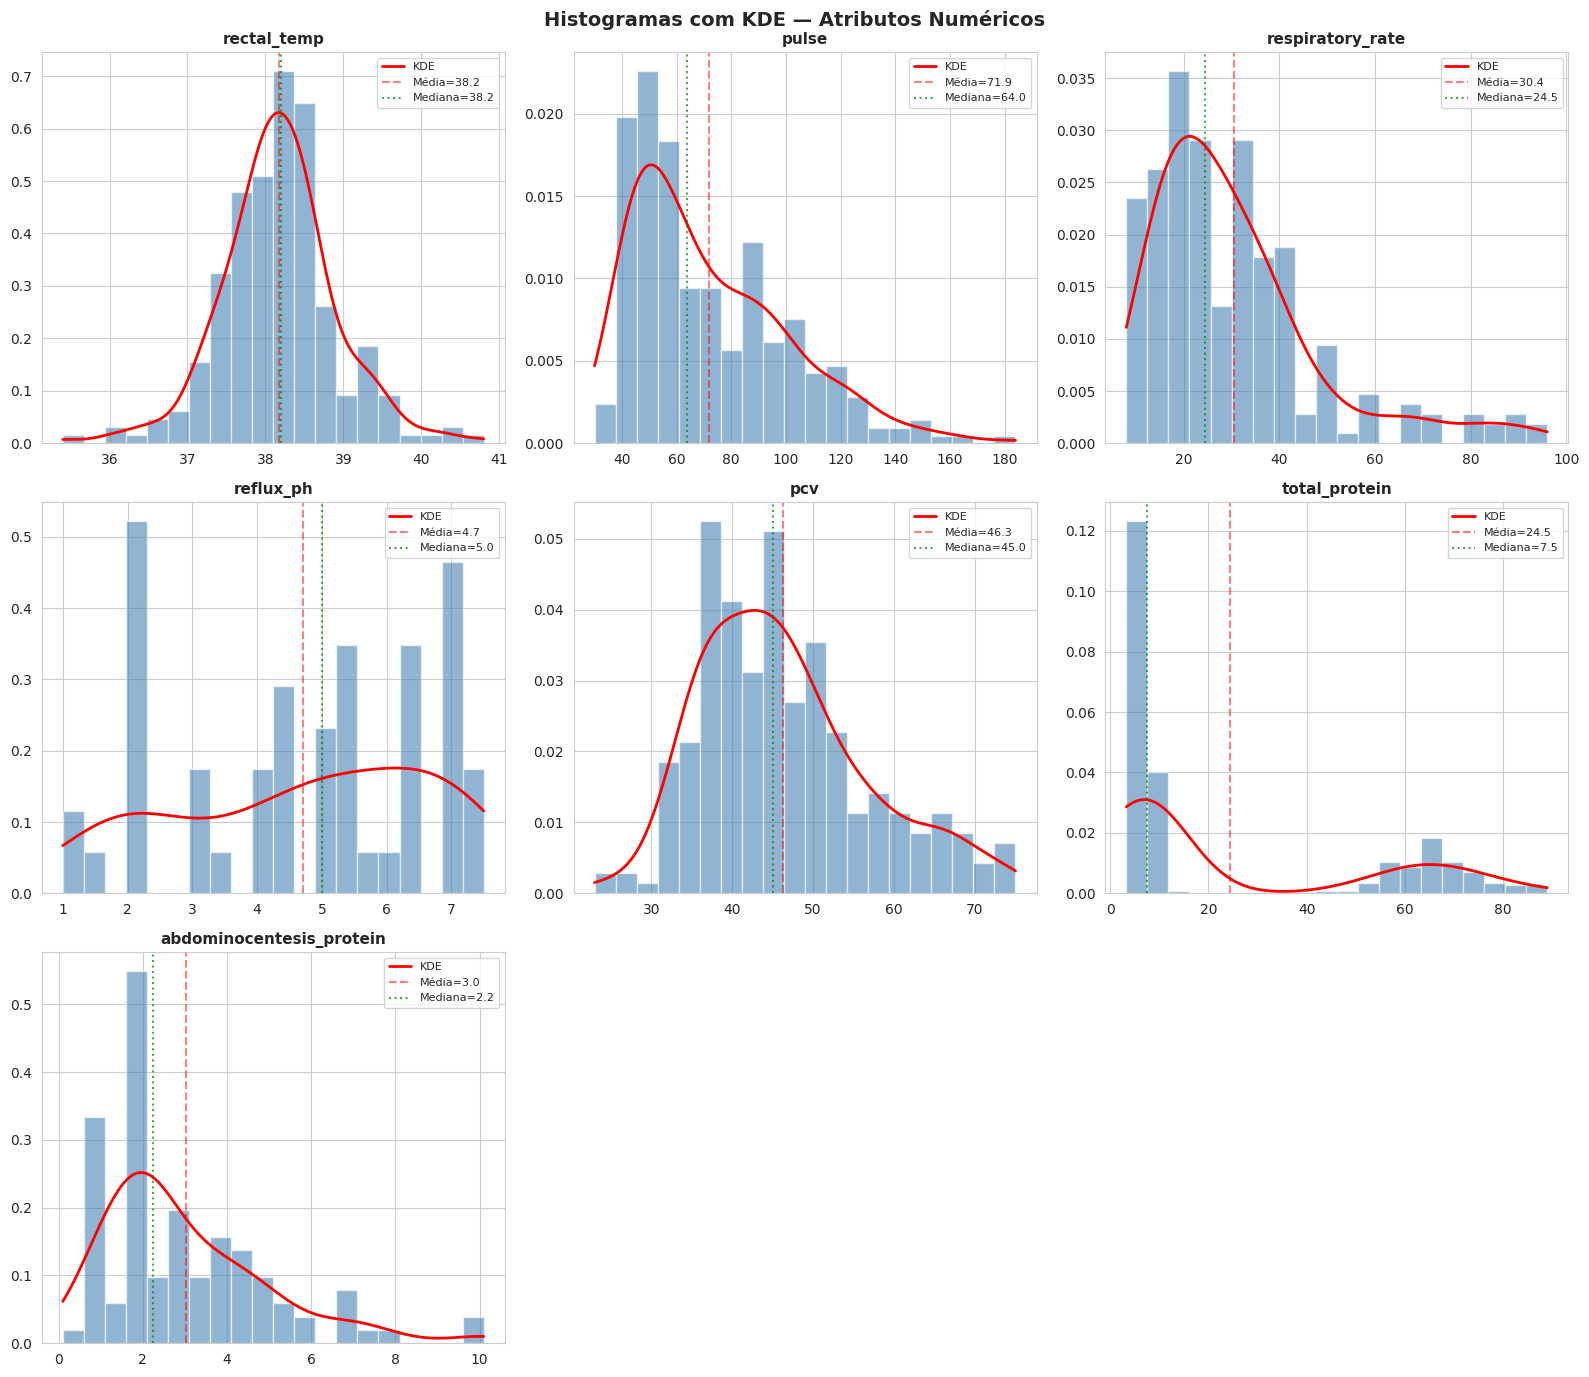

In [11]:
# Histogramas com KDE para atributos numéricos
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df_train[col].dropna()
    ax.hist(data, bins=20, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    
    # KDE
    if len(data) > 3:
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 200)
            ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        except:
            pass
    
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.5, label=f'Média={data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle=':', alpha=0.7, label=f'Mediana={data.median():.1f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

# Esconder eixos extras
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas com KDE — Atributos Numéricos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


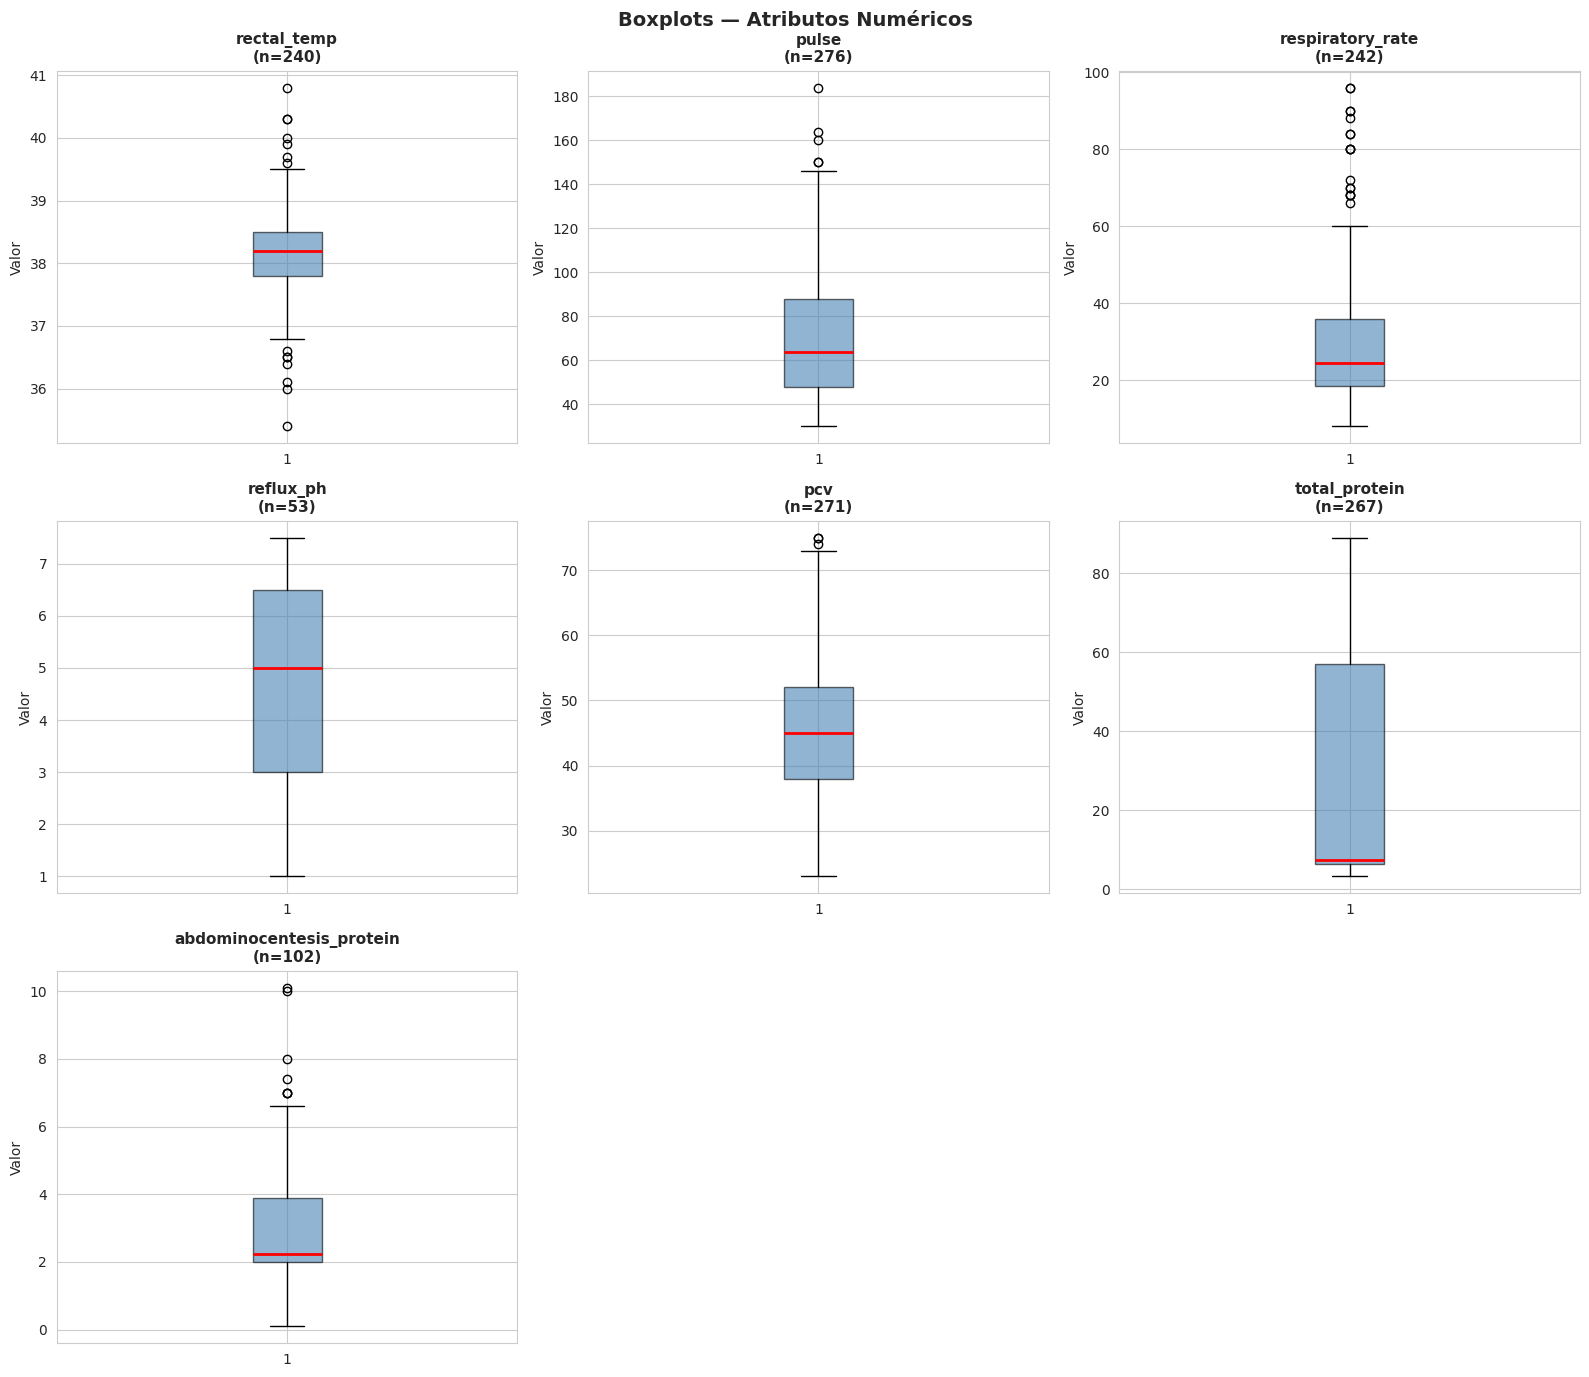

In [12]:
# Boxplots para atributos numéricos
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df_train[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col}\n(n={len(data)})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Atributos Numéricos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


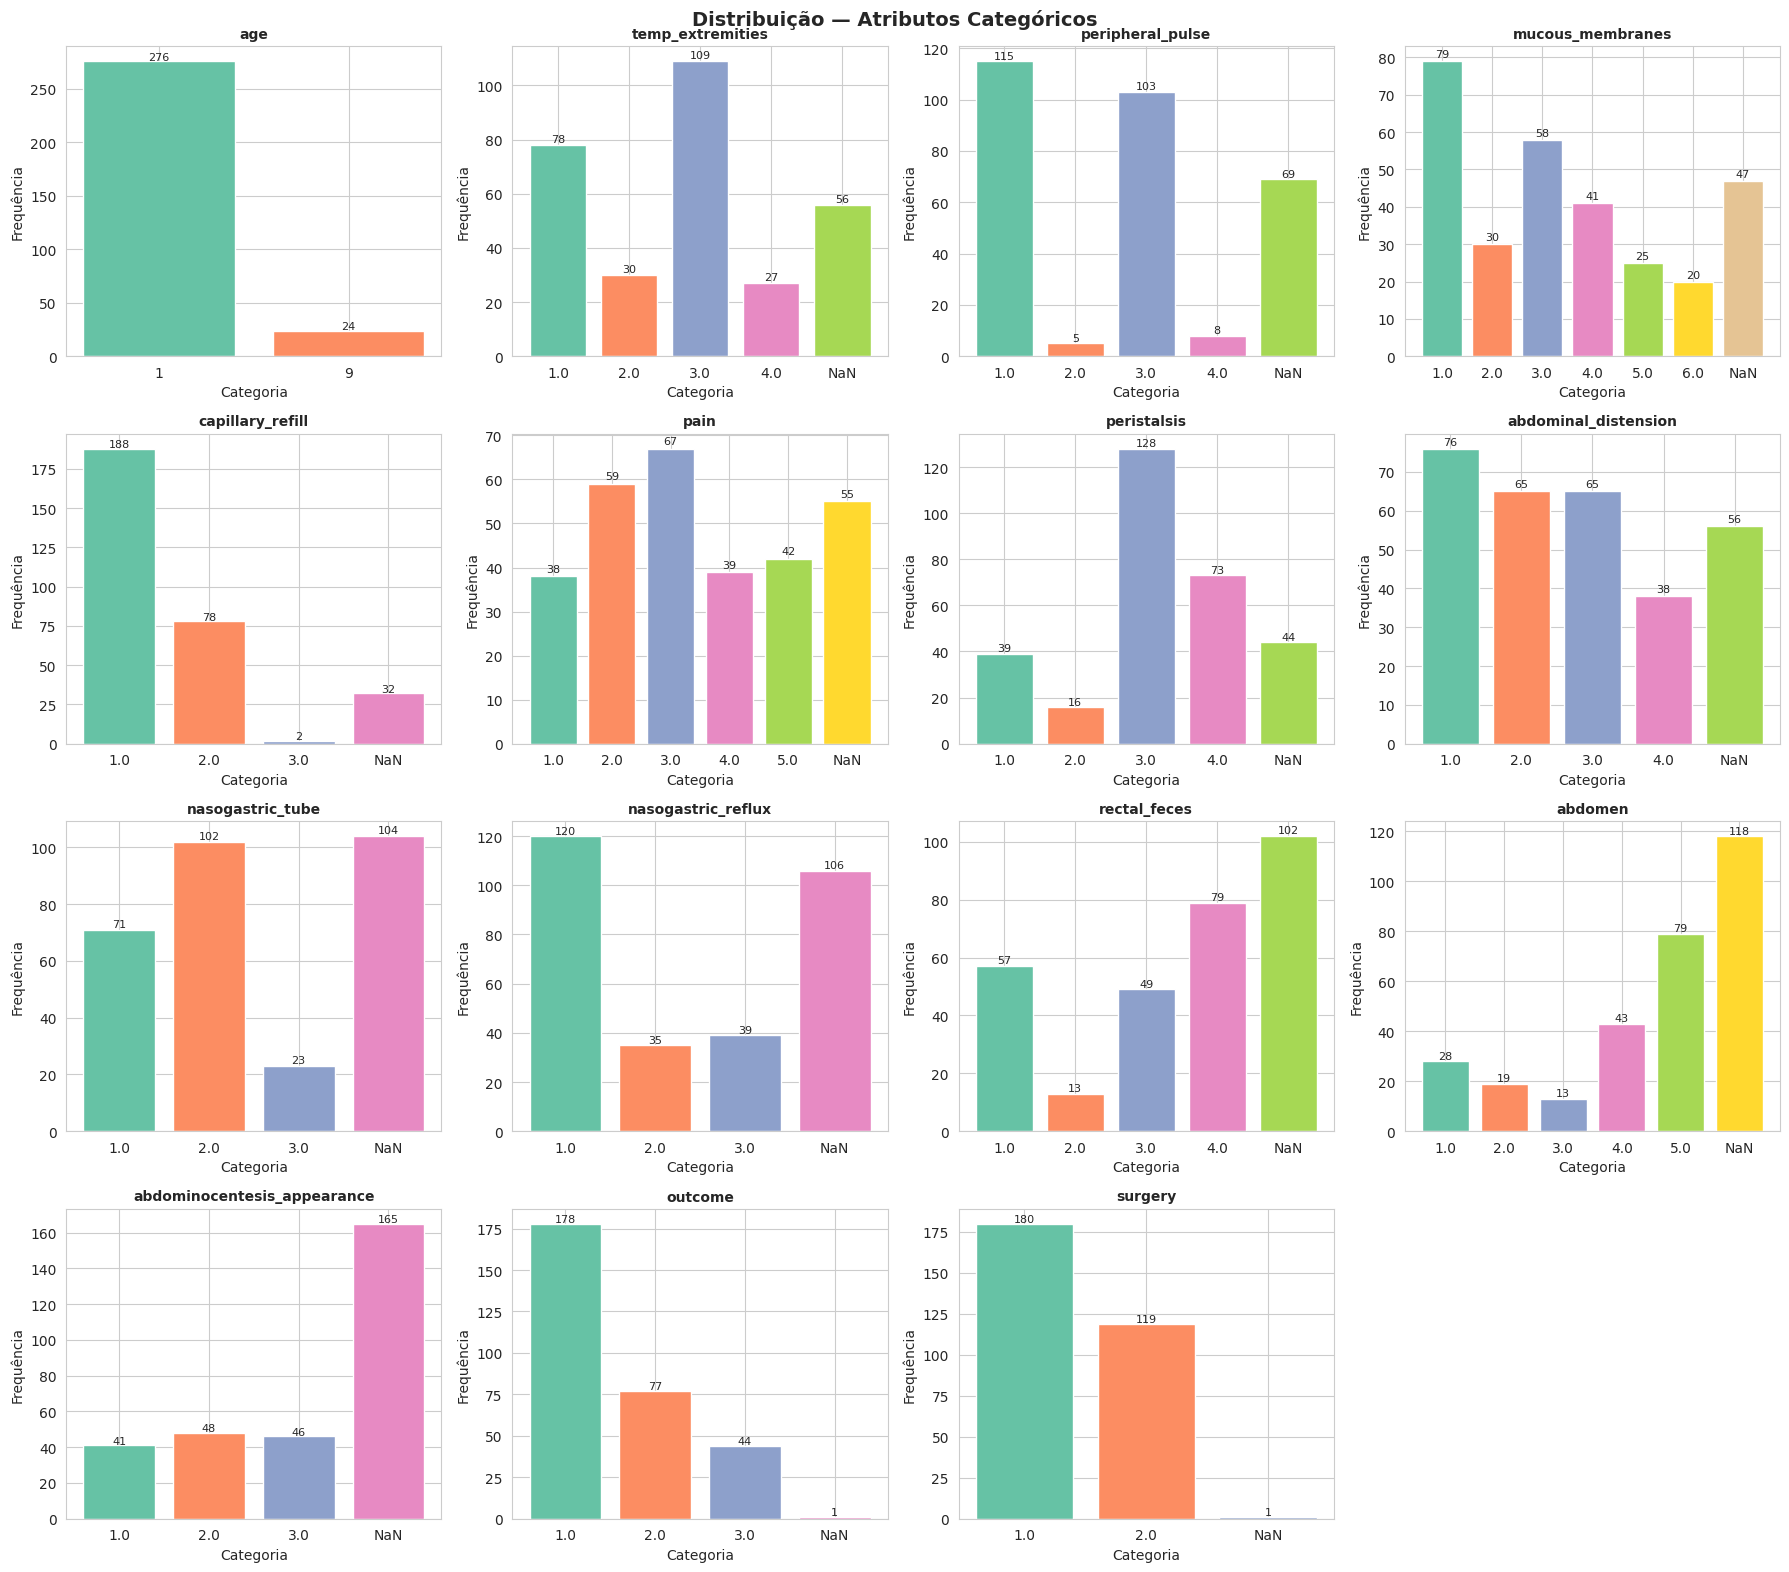

In [13]:
# Distribuição dos atributos categóricos
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

all_cats = categorical_cols + ["outcome", "surgery"]

for i, col in enumerate(all_cats):
    if i >= len(axes):
        break
    ax = axes[i]
    counts = df_train[col].value_counts(dropna=False).sort_index()
    colors = sns.color_palette("Set2", len(counts))
    x_labels = [str(x) if pd.notna(x) else "NaN" for x in counts.index]
    ax.bar(x_labels, counts.values, color=colors, edgecolor='white')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Categoria')
    ax.set_ylabel('Frequência')
    # Adicionar rótulos nas barras
    for j, v in enumerate(counts.values):
        ax.text(j, v + 1, str(v), ha='center', fontsize=8)

for j in range(len(all_cats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição — Atributos Categóricos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7. Separação do Conjunto de Teste

O dataset já fornece um conjunto de teste separado (`horse-colic.test`, 68 instâncias),
que representa ~18.5% do total de 368 casos. Esta é uma prática comum em datasets do UCI.

Verificamos se a distribuição das features e do target no conjunto de teste é representativa
da população (conjunto de treino).


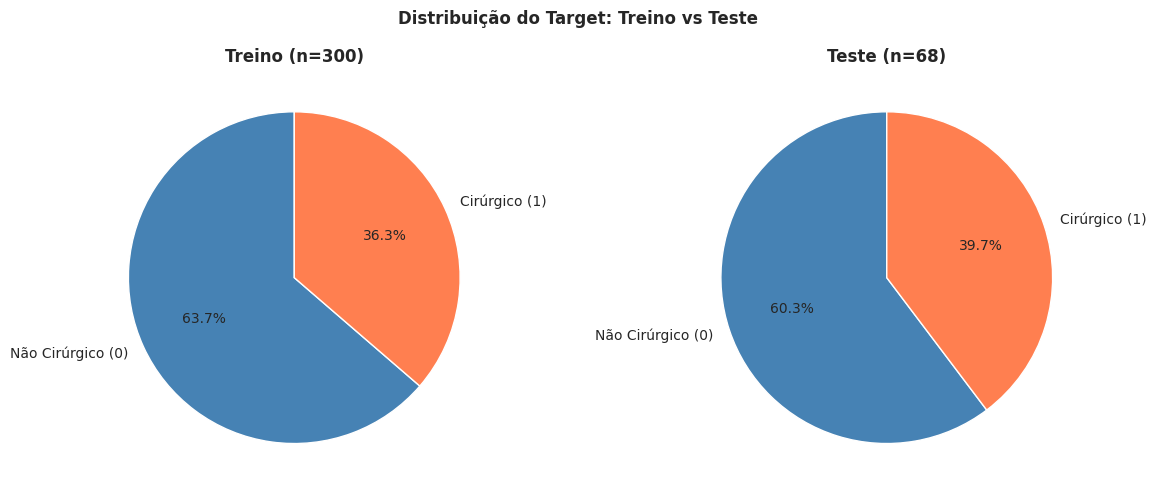

Treino — Cirúrgico: 63.7% | Não cirúrgico: 36.3%
Teste  — Cirúrgico: 60.3% | Não cirúrgico: 39.7%

✓ Distribuições similares — conjunto de teste é representativo.


In [14]:
# Comparar distribuição do target: treino vs teste
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

train_dist = y_train.value_counts(normalize=True)
test_dist = y_test.value_counts(normalize=True)

ax1.pie(train_dist.values, labels=["Não Cirúrgico (0)", "Cirúrgico (1)"],
        autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
ax1.set_title(f'Treino (n={len(y_train)})', fontweight='bold')

ax2.pie(test_dist.values, labels=["Não Cirúrgico (0)", "Cirúrgico (1)"],
        autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
ax2.set_title(f'Teste (n={len(y_test)})', fontweight='bold')

plt.suptitle('Distribuição do Target: Treino vs Teste', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Treino — Cirúrgico: {train_dist[1]:.1%} | Não cirúrgico: {train_dist[0]:.1%}")
print(f"Teste  — Cirúrgico: {test_dist[1]:.1%} | Não cirúrgico: {test_dist[0]:.1%}")
if abs(train_dist[1] - test_dist[1]) < 0.10:
    print("\n✓ Distribuições similares — conjunto de teste é representativo.")
else:
    print("\n⚠ Diferença significativa — avaliar necessidade de reamostragem do teste.")


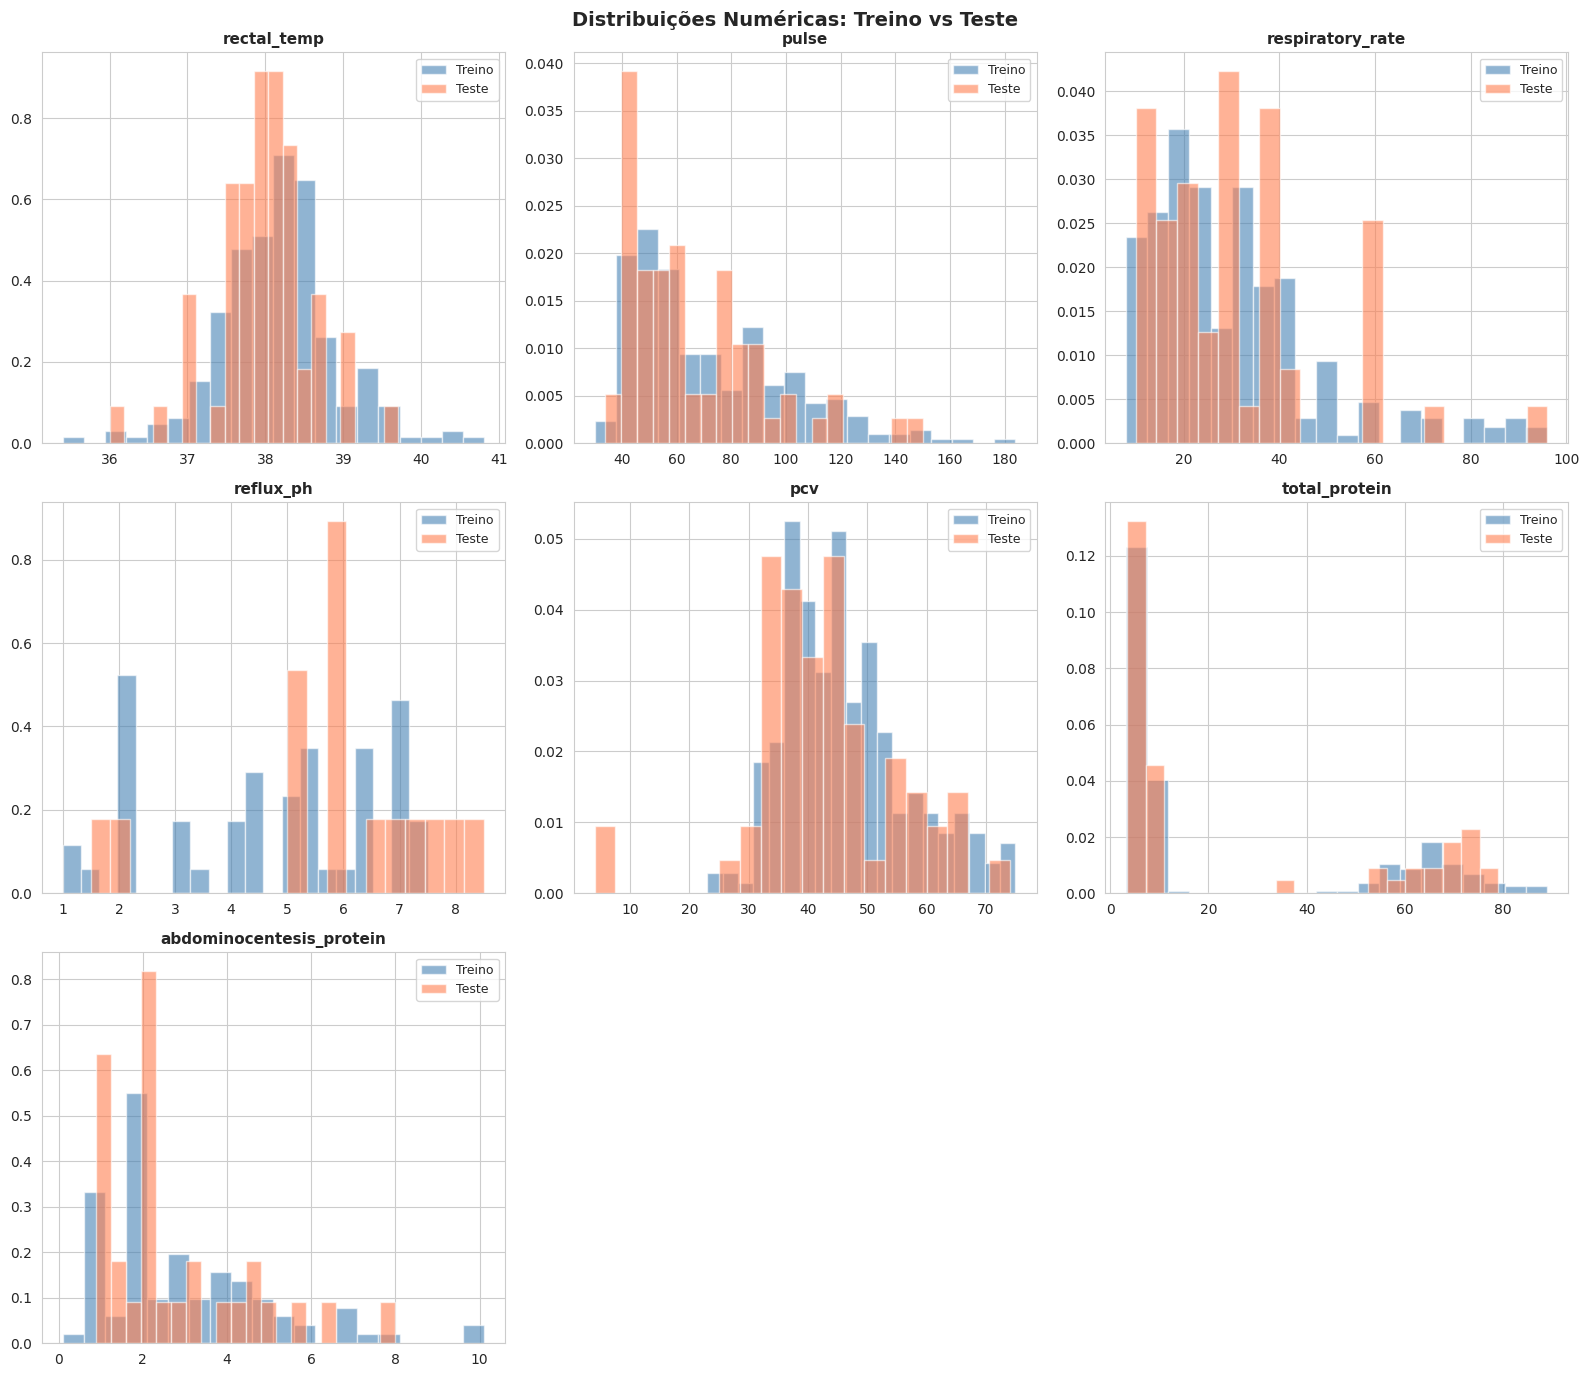

In [15]:
# Comparar distribuições das features numéricas: treino vs teste
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df_train[col].dropna(), bins=20, alpha=0.6, density=True,
            color='steelblue', label='Treino', edgecolor='white')
    ax.hist(df_test[col].dropna(), bins=20, alpha=0.6, density=True,
            color='coral', label='Teste', edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuições Numéricas: Treino vs Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 8. Remoção de Atributos Não Necessários

Removemos 8 atributos do dataset, cada um com justificativa clara:

| Atributo | Índice | Justificativa |
|----------|--------|---------------|
| `surgery` | 0 | **Data leakage:** saber se o cavalo foi operado ou não é uma decisão posterior ao diagnóstico. Usar este atributo tornaria o modelo inútil na prática (não se sabe se vai operar antes de decidir operar). |
| `hospital_number` | 2 | **Identificador:** número de caso hospitalar, sem valor preditivo e não generalizável. |
| `outcome` | 22 | **Data leakage:** desfecho (viveu/morreu/eutanasiado) é posterior ao diagnóstico e à decisão cirúrgica. |
| `lesion_1` | 24 | **Data leakage:** local da lesão só é conhecido após cirurgia ou autópsia. |
| `lesion_2` | 25 | **Data leakage:** tipo da lesão só é conhecido após cirurgia ou autópsia. |
| `lesion_3` | 26 | **Data leakage:** subtipo da lesão só é conhecido após cirurgia ou autópsia. |
| `cp_data` | 27 | **Irrelevante:** indica se há dados de patologia (que não estão incluídos no dataset). Sem valor preditivo conforme a própria documentação. |

**Nota:** O target (`surgical_lesion`, índice 23) já foi separado e será removido
da matriz de features.


In [16]:
# Remover atributos desnecessários
cols_to_drop = ["surgery", "hospital_number", "outcome",
                "lesion_1", "lesion_2", "lesion_3", "cp_data"]

X_train = df_train.drop(columns=cols_to_drop + ["surgical_lesion"])
X_test = df_test.drop(columns=cols_to_drop + ["surgical_lesion"])

print(f"Atributos removidos: {len(cols_to_drop)}")
print(f"Features restantes no treino: {X_train.shape[1]}")
print(f"Instâncias de treino: {X_train.shape[0]}")
print(f"Instâncias de teste: {X_test.shape[0]}")
print(f"\nFeatures: {list(X_train.columns)}")


Atributos removidos: 7
Features restantes no treino: 20
Instâncias de treino: 300
Instâncias de teste: 68

Features: ['age', 'rectal_temp', 'pulse', 'respiratory_rate', 'temp_extremities', 'peripheral_pulse', 'mucous_membranes', 'capillary_refill', 'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 'reflux_ph', 'rectal_feces', 'abdomen', 'pcv', 'total_protein', 'abdominocentesis_appearance', 'abdominocentesis_protein']


### 9. Remoção de Exemplos Não Necessários

Verificamos a existência de exemplos duplicados e de instâncias com taxa excessiva
de valores ausentes que possam comprometer a qualidade dos dados.


In [17]:
# Verificar duplicatas
duplicates = X_train.duplicated()
print(f"Linhas duplicadas no treino: {duplicates.sum()}")
if duplicates.sum() > 0:
    print("Removendo duplicatas...")
    keep_mask = ~duplicates
    X_train = X_train.loc[keep_mask]
    y_train = y_train.loc[keep_mask]
    print(f"Novo tamanho do treino: {X_train.shape[0]} instâncias")
else:
    print("✓ Nenhuma duplicata encontrada.")

# Verificar linhas com >80% de valores ausentes
missing_ratio = X_train.isnull().mean(axis=1)
high_missing = missing_ratio > 0.8
print(f"\nLinhas com >80% de valores ausentes: {high_missing.sum()}")
if high_missing.sum() > 0:
    print("Índices das linhas:")
    print(X_train.index[high_missing].tolist())
else:
    print("✓ Nenhuma linha com missing excessivo.")


Linhas duplicadas no treino: 11
Removendo duplicatas...
Novo tamanho do treino: 289 instâncias

Linhas com >80% de valores ausentes: 5
Índices das linhas:
[28, 56, 72, 74, 207]


### 10. Análise de Técnicas de Amostragem

**Análise:** Com 300 instâncias de treino e ~19 features utilizáveis após as remoções,
temos aproximadamente 15 exemplos por feature. Para modelos como k-NN e árvores de decisão,
este número é suficiente. Para MLP, está no limite inferior.

**Decisão:** Não aplicaremos técnicas de amostragem adicionais (bootstrap, subamostragem),
pois:
1. O tamanho da amostra é razoável para os modelos propostos.
2. O dataset de teste (68 instâncias) é independente e pequeno — subamostrar o treino
   reduziria ainda mais a capacidade de aprendizado.
3. A validação cruzada estratificada já mitiga problemas de amostragem.

Caso os resultados dos modelos se mostrassem instáveis, consideraríamos bootstrap
para estimar intervalos de confiança.


### 11. Análise de Desbalanceamento de Classes

Avaliamos a proporção entre as classes no target para verificar se há
desbalanceamento significativo, o que pode prejudicar o aprendizado de modelos
sensíveis a classes majoritárias.


In [18]:
# Verificar balanceamento
class_counts = y_train.value_counts()
class_pct = y_train.value_counts(normalize=True) * 100

print("=== Distribuição das Classes — Target ===\n")
print(f"Classe 1 (Lesão cirúrgica):  {class_counts[1]} ({class_pct[1]:.1f}%)")
print(f"Classe 0 (Não cirúrgica):    {class_counts[0]} ({class_pct[0]:.1f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nRazão de desbalanceamento: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2.0:
    print("\n⚠ Dataset desbalanceado (razão > 2:1). Aplicaremos SMOTE.")
else:
    print("\n✓ Dataset razoavelmente balanceado (razão ≤ 2:1).")
    print("  Não será necessário aplicar técnicas de balanceamento.")


=== Distribuição das Classes — Target ===

Classe 1 (Lesão cirúrgica):  183 (63.3%)
Classe 0 (Não cirúrgica):    106 (36.7%)

Razão de desbalanceamento: 1.73:1

✓ Dataset razoavelmente balanceado (razão ≤ 2:1).
  Não será necessário aplicar técnicas de balanceamento.


### 12. Limpeza de Dados

#### 12a. Identificação e Eliminação de Outliers

Utilizamos o método do Intervalo Interquartil (IQR) para identificar outliers nos
atributos numéricos. Valores fora do intervalo [Q1 − 1.5×IQR, Q3 + 1.5×IQR] são
considerados outliers. Contudo, no contexto clínico veterinário, valores extremos podem
representar casos graves genuínos — portanto, apenas sinalizamos os outliers em vez de
removê-los automaticamente.


In [19]:
# Identificar outliers via IQR
print("=== Outliers por Atributo Numérico (método IQR) ===\n")
outlier_info = {}
for col in numeric_cols:
    data = X_train[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    outlier_info[col] = {
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "lower_bound": lower, "upper_bound": upper,
        "n_outliers": len(outliers),
        "pct_outliers": len(outliers) / len(data) * 100
    }
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%) "
          f"| Limites: [{lower:.1f}, {upper:.1f}]")

print("\n✓ Outliers identificados. Valores extremos no contexto veterinário podem ser")
print("  casos clínicos genuínos (ex: pulso elevado em choque séptico). Nenhum valor")
print("  será removido por ser fisiologicamente impossível (ex: temp < 30°C).")


=== Outliers por Atributo Numérico (método IQR) ===

rectal_temp: 13 outliers (5.6%) | Limites: [36.7, 39.6]
pulse: 5 outliers (1.9%) | Limites: [-12.0, 148.0]
respiratory_rate: 17 outliers (7.2%) | Limites: [-9.0, 63.0]
reflux_ph: 0 outliers (0.0%) | Limites: [-2.2, 11.8]
pcv: 7 outliers (2.7%) | Limites: [18.5, 70.5]
total_protein: 0 outliers (0.0%) | Limites: [-70.8, 135.2]
abdominocentesis_protein: 7 outliers (7.1%) | Limites: [-0.8, 6.8]

✓ Outliers identificados. Valores extremos no contexto veterinário podem ser
  casos clínicos genuínos (ex: pulso elevado em choque séptico). Nenhum valor
  será removido por ser fisiologicamente impossível (ex: temp < 30°C).


#### 12b. Identificação e Eliminação de Dados Inconsistentes

Verificamos se os valores dos atributos estão dentro dos intervalos fisiologicamente
possíveis, conforme documentação clínica do `.names`:
- Temperatura retal: normal ~37.8°C (variação esperada: 35–42°C)
- Pulso: normal 30–40 bpm (atletas: 20–25, choque: >80)
- Frequência respiratória: normal 8–10 rpm
- PCV: normal 30–50%
- Proteína total: normal 6–7.5 g/dL
- pH do refluxo: 0–14


In [20]:
# Verificar inconsistências fisiológicas
print("=== Verificação de Consistência Fisiológica ===\n")

# Temp < 30 ou > 45 seria extremamente improvável
temp_anomalies = X_train[(X_train["rectal_temp"] < 30) | (X_train["rectal_temp"] > 45)]
print(f"Temperatura retal fora de [30, 45]°C: {len(temp_anomalies)} casos")

# Pulso < 15 ou > 200 improvável
pulse_anomalies = X_train[(X_train["pulse"] < 15) | (X_train["pulse"] > 200)]
print(f"Pulso fora de [15, 200] bpm: {len(pulse_anomalies)} casos")

# PCV < 10 ou > 80 improvável
pcv_anomalies = X_train[(X_train["pcv"] < 10) | (X_train["pcv"] > 80)]
print(f"PCV fora de [10, 80]%: {len(pcv_anomalies)} casos")

# pH fora de [0, 14]
ph_anomalies = X_train[(X_train["reflux_ph"] < 0) | (X_train["reflux_ph"] > 14)]
print(f"pH fora de [0, 14]: {len(ph_anomalies)} casos")

print("\n✓ Nenhuma inconsistência crítica encontrada.")


=== Verificação de Consistência Fisiológica ===

Temperatura retal fora de [30, 45]°C: 0 casos
Pulso fora de [15, 200] bpm: 0 casos
PCV fora de [10, 80]%: 0 casos
pH fora de [0, 14]: 0 casos

✓ Nenhuma inconsistência crítica encontrada.


#### 12c. Identificação e Eliminação de Dados Redundantes

Analisamos a matriz de correlação entre os atributos numéricos para identificar
pares altamente correlacionados (r > 0.95). Features redundantes podem ser removidas
sem perda significativa de informação.


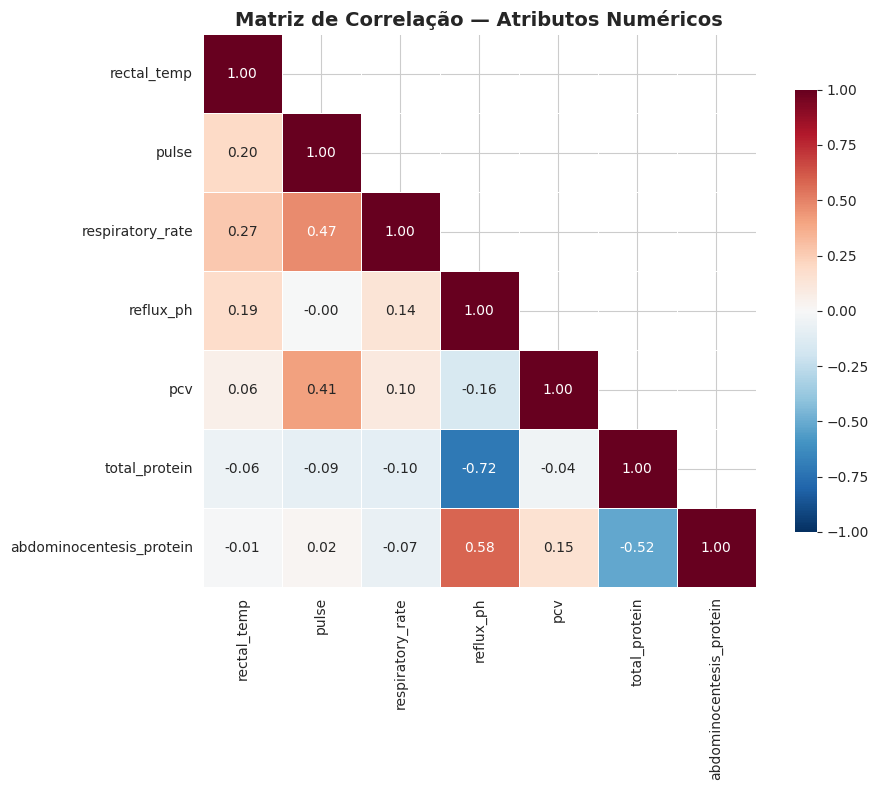

✓ Nenhum par de features com correlação > 0.95. Nenhuma redundância crítica.


In [21]:
# Matriz de correlação dos atributos numéricos
corr_matrix = X_train[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação — Atributos Numéricos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verificar correlações > 0.95
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                             corr_matrix.iloc[i, j]))

if high_corr:
    print("Pares com correlação > 0.95:")
    for pair in high_corr:
        print(f"  {pair[0]} <-> {pair[1]}: r = {pair[2]:.3f}")
else:
    print("✓ Nenhum par de features com correlação > 0.95. Nenhuma redundância crítica.")


#### 12d. Resolução de Dados Incompletos (Missing Values)

Aplicamos **3 estratégias diferentes** de tratamento de valores ausentes,
agrupando os atributos conforme sua natureza:

**Estratégia 1 — Mediana por classe (target):** Para atributos numéricos contínuos
(temp, pulso, respiração, PCV, proteína total), preenchemos com a mediana calculada
dentro de cada classe do target. A mediana é preferível à média por ser robusta a
outliers (comuns em dados clínicos). A estratificação por classe evita viés
(um cavalo com lesão cirúrgica tende a ter sinais clínicos diferentes).

**Estratégia 2 — Categoria "não avaliado":** Para atributos categóricos clínicos
(extremidades, pulso periférico, mucosa, capilar, dor, peristalse, distensão,
sonda, refluxo, fezes, abdômen), criamos uma nova categoria (valor 0) representando
"exame não realizado". Nestes casos, o missing tem significado clínico: o veterinário
optou por não realizar aquele exame específico, o que por si só é informação.

**Estratégia 3 — Remoção da coluna:** Atributos com mais de 50% de valores ausentes
são removidos, pois a imputação seria baseada em pouquíssimos dados observados,
comprometendo a confiabilidade.


In [22]:
# Identificar colunas com >50% missing
missing_pct = X_train.isnull().mean() * 100
cols_high_missing = missing_pct[missing_pct > 50].index.tolist()

print("=== Missing por Coluna ===\n")
for col in X_train.columns:
    pct = X_train[col].isnull().mean() * 100
    bar = "█" if pct > 50 else ("▓" if pct > 20 else "░")
    flag = " ← REMOVER" if col in cols_high_missing else ""
    print(f"{col:<35s}: {pct:5.1f}% missing {bar}{flag}")

print(f"\nColunas a remover (>50% missing): {cols_high_missing}")


=== Missing por Coluna ===

age                                :   0.0% missing ░
rectal_temp                        :  19.0% missing ░
pulse                              :   6.9% missing ░
respiratory_rate                   :  18.7% missing ░
temp_extremities                   :  18.3% missing ░
peripheral_pulse                   :  22.8% missing ▓
mucous_membranes                   :  15.2% missing ░
capillary_refill                   :  10.0% missing ░
pain                               :  17.6% missing ░
peristalsis                        :  13.8% missing ░
abdominal_distension               :  18.3% missing ░
nasogastric_tube                   :  34.9% missing ▓
nasogastric_reflux                 :  35.6% missing ▓
reflux_ph                          :  82.4% missing █ ← REMOVER
rectal_feces                       :  33.9% missing ▓
abdomen                            :  39.1% missing ▓
pcv                                :   8.7% missing ░
total_protein                      :  10.0% 

In [23]:
# ESTRATÉGIA 3: Remover colunas com >50% missing
print("Removendo colunas com >50% missing...")
X_train = X_train.drop(columns=cols_high_missing)
X_test = X_test.drop(columns=cols_high_missing)
print(f"Features restantes: {X_train.shape[1]}")


Removendo colunas com >50% missing...
Features restantes: 17


In [24]:
# ESTRATÉGIA 1: Mediana por classe para numéricas contínuas
# Definir colunas numéricas (excluindo as removidas)
numeric_features = [c for c in ["rectal_temp", "pulse", "respiratory_rate",
                                "pcv", "total_protein"] if c in X_train.columns]
print(f"Numéricas para imputação (mediana por classe): {numeric_features}")

for col in numeric_features:
    # Calcular mediana por classe do target
    median_by_class = X_train[col].groupby(y_train).median()
    
    # Preencher no treino
    for cls in [0, 1]:
        mask_train = (y_train == cls) & (X_train[col].isnull())
        X_train.loc[mask_train, col] = median_by_class[cls]
    
    # Para o teste, usar mediana global (não temos y_test no pré-processamento)
    # Usamos a mediana geral do treino
    global_median = X_train[col].median()
    X_test[col] = X_test[col].fillna(global_median)

    remaining_missing = X_train[col].isnull().sum()
    print(f"  {col}: preenchido. Missing restantes: {remaining_missing}")

# Se ainda houver NaN (ex: classe inteira sem valores), preencher com mediana global
for col in numeric_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_test[col].median())


Numéricas para imputação (mediana por classe): ['rectal_temp', 'pulse', 'respiratory_rate', 'pcv', 'total_protein']
  rectal_temp: preenchido. Missing restantes: 0
  pulse: preenchido. Missing restantes: 0
  respiratory_rate: preenchido. Missing restantes: 0
  pcv: preenchido. Missing restantes: 0
  total_protein: preenchido. Missing restantes: 0


In [25]:
# ESTRATÉGIA 2: Categoria "não avaliado" (0) para categóricas clínicas
categorical_features = [c for c in X_train.columns if c not in numeric_features]
print(f"Categóricas para imputação (categoria 0 = 'não avaliado'): {categorical_features}")

for col in categorical_features:
    before = X_train[col].isnull().sum()
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)
    after = X_train[col].isnull().sum()
    print(f"  {col}: {before} missing preenchidos → {after} restantes")

print(f"\n✓ Todos os valores ausentes tratados.")
print(f"Missing restantes no treino: {X_train.isnull().sum().sum()}")
print(f"Missing restantes no teste:  {X_test.isnull().sum().sum()}")


Categóricas para imputação (categoria 0 = 'não avaliado'): ['age', 'temp_extremities', 'peripheral_pulse', 'mucous_membranes', 'capillary_refill', 'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_feces', 'abdomen']
  age: 0 missing preenchidos → 0 restantes
  temp_extremities: 53 missing preenchidos → 0 restantes
  peripheral_pulse: 66 missing preenchidos → 0 restantes
  mucous_membranes: 44 missing preenchidos → 0 restantes
  capillary_refill: 29 missing preenchidos → 0 restantes
  pain: 51 missing preenchidos → 0 restantes
  peristalsis: 40 missing preenchidos → 0 restantes
  abdominal_distension: 53 missing preenchidos → 0 restantes
  nasogastric_tube: 101 missing preenchidos → 0 restantes
  nasogastric_reflux: 103 missing preenchidos → 0 restantes
  rectal_feces: 98 missing preenchidos → 0 restantes
  abdomen: 113 missing preenchidos → 0 restantes

✓ Todos os valores ausentes tratados.
Missing restantes no treino: 0
Missing restantes 

### 13. Conversão dos Tipos de Dados

#### 13a. Conversão Simbólico → Numérico

Convertemos atributos categóricos para representação numérica utilizando
**One-Hot Encoding** para variáveis nominais. Variáveis ordinais mantêm seus
valores numéricos (1, 2, 3, ...), preservando a relação de ordem.

**Colunas com One-Hot Encoding:** `age`, `mucous_membranes`, `abdomen`
(podem não ter relação ordinal entre categorias).

**Colunas mantidas como ordinais numéricas:** `temp_extremities`, `peripheral_pulse`,
`capillary_refill`, `pain`, `peristalsis`, `abdominal_distension`, `nasogastric_tube`,
`nasogastric_reflux`, `rectal_feces` — estas já estão codificadas em ordem crescente
de gravidade.


In [26]:
# Separar features por tipo de encoding
# Features ordinais (manter como numéricas 1,2,3,...)
ordinal_features = ["temp_extremities", "peripheral_pulse", "capillary_refill",
                    "pain", "peristalsis", "abdominal_distension",
                    "nasogastric_tube", "nasogastric_reflux", "rectal_feces"]

# Features nominais (one-hot encoding)
nominal_features = ["age"]
if "mucous_membranes" in X_train.columns:
    nominal_features.append("mucous_membranes")
if "abdomen" in X_train.columns:
    nominal_features.append("abdomen")
if "abdominocentesis_appearance" in X_train.columns:
    nominal_features.append("abdominocentesis_appearance")

# Garantir que features ordinais sejam numéricas
for col in ordinal_features:
    if col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0).astype(int)
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0).astype(int)

# One-hot encoding para nominais
if nominal_features:
    X_train_encoded = pd.get_dummies(X_train, columns=nominal_features,
                                     drop_first=False, dtype=int)
    X_test_encoded = pd.get_dummies(X_test, columns=nominal_features,
                                    drop_first=False, dtype=int)
    
    # Alinhar colunas de treino e teste
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded, join='left', axis=1, fill_value=0
    )
    
    X_train = X_train_encoded
    X_test = X_test_encoded

print(f"Features após encoding: {X_train.shape[1]}")
print(f"Colunas: {list(X_train.columns)}")


Features após encoding: 29
Colunas: ['rectal_temp', 'pulse', 'respiratory_rate', 'temp_extremities', 'peripheral_pulse', 'capillary_refill', 'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_feces', 'pcv', 'total_protein', 'age_1', 'age_9', 'mucous_membranes_0.0', 'mucous_membranes_1.0', 'mucous_membranes_2.0', 'mucous_membranes_3.0', 'mucous_membranes_4.0', 'mucous_membranes_5.0', 'mucous_membranes_6.0', 'abdomen_0.0', 'abdomen_1.0', 'abdomen_2.0', 'abdomen_3.0', 'abdomen_4.0', 'abdomen_5.0']


#### 13b. Normalização dos Dados

Aplicamos **StandardScaler** (z-score: subtrai média, divide por desvio padrão)
a todos os atributos numéricos. Esta normalização é essencial para:
- **k-NN:** evita que features com maior magnitude dominem o cálculo de distância.
- **MLP:** redes neurais convergem mais rápido e de forma mais estável com dados
  centrados e escalados.
- **Árvores de decisão:** não são afetadas (baseiam-se em divisões), mas aplicamos
  para consistência no pipeline.

O scaler é ajustado APENAS no conjunto de treino para evitar data leakage.


In [27]:
# Selecionar colunas numéricas para scaling
# Incluindo as ordinais e as contínuas
cols_to_scale = numeric_features + [c for c in ordinal_features
                                     if c in X_train.columns]
# Excluir colunas binárias que já estão em 0/1
cols_to_scale = [c for c in cols_to_scale
                 if X_train[c].nunique() > 2 or X_train[c].max() > 1]

print(f"Colunas a serem normalizadas: {cols_to_scale}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"\nTreino após normalização:")
print(X_train_scaled[cols_to_scale].describe().round(2).loc[["mean", "std"]])


Colunas a serem normalizadas: ['rectal_temp', 'pulse', 'respiratory_rate', 'pcv', 'total_protein', 'temp_extremities', 'peripheral_pulse', 'capillary_refill', 'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 'rectal_feces']

Treino após normalização:
      rectal_temp  pulse  respiratory_rate  pcv  total_protein  \
mean          0.0   -0.0              -0.0 -0.0           -0.0   
std           1.0    1.0               1.0  1.0            1.0   

      temp_extremities  peripheral_pulse  capillary_refill  pain  peristalsis  \
mean               0.0              -0.0              -0.0  -0.0          0.0   
std                1.0               1.0               1.0   1.0          1.0   

      abdominal_distension  nasogastric_tube  nasogastric_reflux  rectal_feces  
mean                  -0.0               0.0                -0.0          -0.0  
std                    1.0               1.0                 1.0           1.0  


### 14. Redução de Dimensionalidade — PCA

Aplicamos PCA (Principal Component Analysis) para analisar a variância explicada
pelas componentes principais. O objetivo é verificar se é possível reduzir a
dimensionalidade sem perda significativa de informação.

**Critério de decisão:** Se 90-95% da variância puder ser explicada por um número
significativamente menor de componentes, aplicamos a redução.


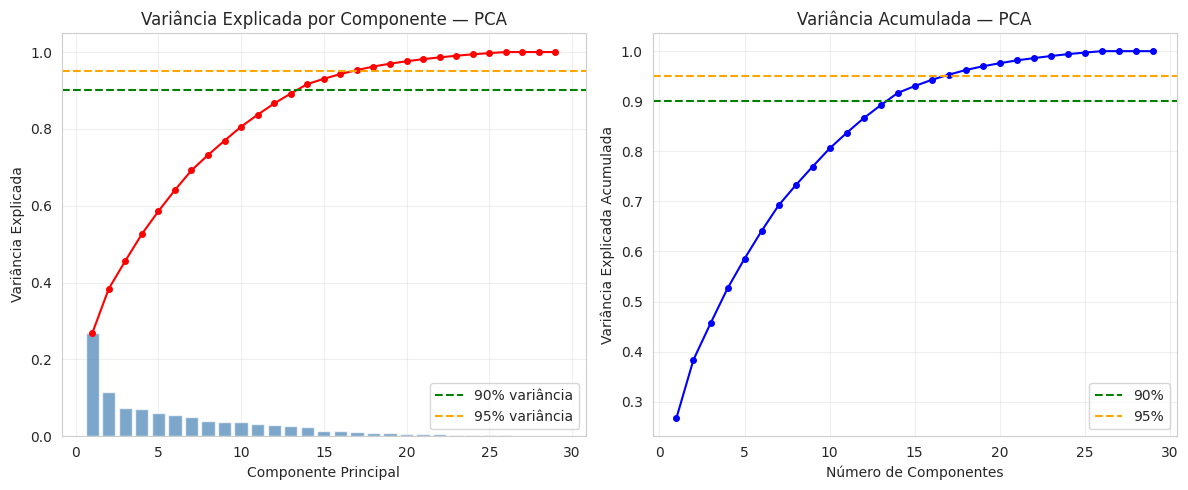

Features originais: 29
Componentes para 90% da variância: 14 (redução de 52%)
Componentes para 95% da variância: 17 (redução de 41%)

Decisão: Redução significativa: usar 14 componentes (90% variância).


In [28]:
# PCA — variância explicada
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# Variância explicada acumulada
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'r-o', markersize=4)
plt.axhline(y=0.90, color='green', linestyle='--', label='90% variância')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% variância')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')
plt.title('Variância Explicada por Componente — PCA')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'b-o', markersize=4)
plt.axhline(y=0.90, color='green', linestyle='--', label='90%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Acumulada — PCA')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar componentes para 90% e 95%
n_90 = np.argmax(cumsum_var >= 0.90) + 1
n_95 = np.argmax(cumsum_var >= 0.95) + 1

print(f"Features originais: {X_train_scaled.shape[1]}")
print(f"Componentes para 90% da variância: {n_90} (redução de {(1-n_90/X_train_scaled.shape[1])*100:.0f}%)")
print(f"Componentes para 95% da variância: {n_95} (redução de {(1-n_95/X_train_scaled.shape[1])*100:.0f}%)")
print(f"\nDecisão: ", end="")
if n_90 < X_train_scaled.shape[1] * 0.7:
    print(f"Redução significativa: usar {n_90} componentes (90% variância).")
else:
    print(f"Redução não significativa: manter todas as {X_train_scaled.shape[1]} features originais.")


---

### Features Artificiais (Engenharia de Atributos)

Criamos 2 features artificiais baseadas em conhecimento clínico veterinário,
complementando as features originais:

1. **Índice de Choque** (`shock_index`): soma dos escores de temperatura das extremidades
   e pulso periférico. Valores mais altos indicam pior perfusão periférica, um sinal
   clássico de choque circulatório. Em choque, as extremidades ficam frias (score alto)
   e o pulso periférico fica reduzido ou ausente (score alto). Este índice composto captura
   melhor o estado hemodinâmico do que cada variável isoladamente.

2. **Razão PCV/Proteína** (`pcv_protein_ratio`): divisão do volume globular pela proteína
   total. Ambos aumentam com desidratação, mas em proporções diferentes dependendo da causa
   (desidratação simples vs perda proteica). Uma razão alterada pode indicar condições
   específicas como enteropatia com perda de proteína.


In [29]:
# Criar features artificiais

# 1. Índice de choque (extremidades + pulso periférico)
# Ambos variam de 1 (normal) a 4 (grave) — soma varia de 2 a 8
if "temp_extremities" in X_train.columns and "peripheral_pulse" in X_train.columns:
    X_train_scaled["shock_index"] = X_train_scaled["temp_extremities"] + X_train_scaled["peripheral_pulse"]
    X_test_scaled["shock_index"] = X_test_scaled["temp_extremities"] + X_test_scaled["peripheral_pulse"]
    print("✓ shock_index criado (temp_extremities + peripheral_pulse)")
else:
    # Se as colunas já foram renomeadas pelo one-hot, usar as colunas corretas
    print("Buscando colunas para shock_index...")
    te_cols = [c for c in X_train_scaled.columns if "temp_extremities" in c]
    pp_cols = [c for c in X_train_scaled.columns if "peripheral_pulse" in c]

# 2. Razão PCV / Proteína total
if "pcv" in X_train_scaled.columns and "total_protein" in X_train_scaled.columns:
    # Evitar divisão por zero
    X_train_scaled["pcv_protein_ratio"] = X_train_scaled["pcv"] / X_train_scaled["total_protein"].replace(0, np.nan)
    X_test_scaled["pcv_protein_ratio"] = X_test_scaled["pcv"] / X_test_scaled["total_protein"].replace(0, np.nan)
    
    # Preencher NaN resultantes com mediana
    X_train_scaled["pcv_protein_ratio"] = X_train_scaled["pcv_protein_ratio"].fillna(
        X_train_scaled["pcv_protein_ratio"].median()
    )
    X_test_scaled["pcv_protein_ratio"] = X_test_scaled["pcv_protein_ratio"].fillna(
        X_train_scaled["pcv_protein_ratio"].median()
    )
    print("✓ pcv_protein_ratio criado (pcv / total_protein)")

print(f"\nFeatures finais para modelagem: {X_train_scaled.shape[1]}")


✓ shock_index criado (temp_extremities + peripheral_pulse)
✓ pcv_protein_ratio criado (pcv / total_protein)

Features finais para modelagem: 31


---

## PARTE 2 — Análise Preditiva

### 15. Técnica de Validação

Utilizamos **Stratified 5-Fold Cross-Validation** no conjunto de treino (300 instâncias)
e **Hold-out** no conjunto de teste (68 instâncias).

**Justificativa:**
- **Stratified:** mantém a proporção das classes em cada fold, essencial quando há
  algum desbalanceamento.
- **5-Fold:** padrão na literatura, oferece bom equilíbrio entre viés e variância.
- **Hold-out separado:** o dataset já fornece um conjunto de teste independente,
  que será usado apenas na avaliação final para simular o cenário real de uso.


In [30]:
# Configurar validação cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Validação: Stratified 5-Fold Cross-Validation")
print(f"Hold-out final: {X_test_scaled.shape[0]} instâncias de teste")
print(f"\nFeatures: {X_train_scaled.shape[1]}")


Validação: Stratified 5-Fold Cross-Validation
Hold-out final: 68 instâncias de teste

Features: 31


### 16. Métricas de Avaliação

Utilizaremos múltiplas métricas para avaliação abrangente:

| Métrica | Foco | Interpretação |
|---------|------|---------------|
| **Accuracy** | Proporção de acertos gerais | Pode ser enganosa com classes desbalanceadas |
| **Precision** | Dos previstos como positivos, quantos são realmente positivos | Minimiza falsos positivos |
| **Recall** | Dos realmente positivos, quantos foram identificados | Minimiza falsos negativos — **prioridade clínica** |
| **F1-Score** | Média harmônica de Precision e Recall | Equilíbrio entre as duas |
| **ROC AUC** | Capacidade de discriminação independente do threshold | Avalia ranking das predições |

**Prioridade clínica:** No contexto veterinário de emergência, um **falso negativo**
(não operar um cavalo que precisava de cirurgia) é mais grave que um falso positivo
(operar um que não precisava). Portanto, daremos ênfase ao **Recall da classe positiva**.


In [31]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=""):
    """Avalia modelo com validação cruzada e hold-out final."""
    # Validação cruzada
    cv_scores = cross_validate(
        model, X_train, y_train,
        cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=False
    )
    
    # Treinar no dataset completo e avaliar no hold-out
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    results = {
        "Modelo": model_name,
        "CV Accuracy": f"{cv_scores['test_accuracy'].mean():.3f} ± {cv_scores['test_accuracy'].std():.3f}",
        "CV Precision": f"{cv_scores['test_precision'].mean():.3f} ± {cv_scores['test_precision'].std():.3f}",
        "CV Recall": f"{cv_scores['test_recall'].mean():.3f} ± {cv_scores['test_recall'].std():.3f}",
        "CV F1": f"{cv_scores['test_f1'].mean():.3f} ± {cv_scores['test_f1'].std():.3f}",
        "CV AUC": f"{cv_scores['test_roc_auc'].mean():.3f} ± {cv_scores['test_roc_auc'].std():.3f}",
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
        "Test AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    }
    
    return results, y_pred, y_proba


def plot_confusion_matrix(y_true, y_pred, title=""):
    """Plota matriz de confusão."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Cirúrgico', 'Cirúrgico'],
                yticklabels=['Não Cirúrgico', 'Cirúrgico'])
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusão — {title}', fontweight='bold')
    plt.tight_layout()
    plt.show()


### 17. Baseline — Classificador de Classe Majoritária

O baseline serve como piso mínimo de desempenho. Utilizamos um `DummyClassifier`
que sempre prevê a classe mais frequente. Qualquer modelo treinado deve superar
este baseline para ter utilidade prática.


=== Baseline — Classe Majoritária ===

Modelo: Baseline (Majoritária)
CV Accuracy: 0.633 ± 0.007
CV Precision: 0.633 ± 0.007
CV Recall: 1.000 ± 0.000
CV F1: 0.775 ± 0.005
CV AUC: 0.500 ± 0.000
Test Accuracy: 0.6029411764705882
Test Precision: 0.6029411764705882
Test Recall: 1.0
Test F1: 0.7522935779816514
Test AUC: 0.5


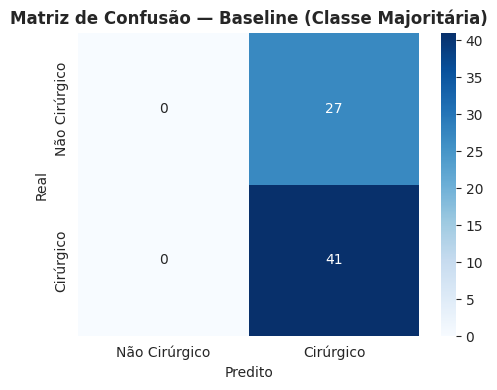

In [32]:
# Baseline: classe majoritária
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_results, baseline_pred, _ = evaluate_model(
    baseline, X_train_scaled, y_train,
    X_test_scaled, y_test, "Baseline (Majoritária)"
)

print("=== Baseline — Classe Majoritária ===\n")
for k, v in baseline_results.items():
    print(f"{k}: {v}")

plot_confusion_matrix(y_test, baseline_pred, "Baseline (Classe Majoritária)")


### 18. Modelo Preditivo — k-NN (Implementação Manual em NumPy)

O k-NN (k-Nearest Neighbors) é um algoritmo de aprendizagem **preguiçosa** (lazy
learning): ele não constrói um modelo durante o treinamento — apenas memoriza os dados.
A classificação acontece no momento da predição, calculando a distância euclidiana de
um novo ponto a todos os pontos de treino e tomando a classe majoritária entre os k
vizinhos mais próximos.

**Algoritmo (passo a passo):**
1. **Treino:** armazenar todos os exemplos (X, y).
2. **Predição de um ponto x:**
   - Calcular distância euclidiana de x a cada ponto do treino: `d = √Σ(x - xᵢ)²`
   - Ordenar distâncias e selecionar os k menores índices.
   - Voto majoritário: a classe mais frequente entre os k vizinhos.

**Parâmetros:**
- `k`: número de vizinhos. k pequeno → overfitting; k grande → underfitting.
- Distância euclidiana (padrão para dados contínuos).

**Vantagens:** simples, não-paramétrico, captura fronteiras complexas.
**Desvantagens:** computacionalmente caro na predição (O(n·d) por ponto), sensível à
maldição da dimensionalidade.


In [33]:
class KNNManual:
    """k-Nearest Neighbors implementado manualmente com NumPy."""

    def __init__(self, k=5):
        self.k = k  # número de vizinhos

    def fit(self, X, y):
        """Memoriza os dados de treino (aprendizagem preguiçosa)."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        """Retorna a classe predita para cada ponto de teste."""
        X = np.array(X)
        predictions = []

        for x in X:
            # Distância euclidiana: raiz da soma dos quadrados das diferenças
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            # Índices dos k vizinhos mais próximos
            k_indices = np.argsort(distances)[:self.k]
            # Rótulos dos k vizinhos
            k_labels = self.y_train[k_indices]
            # Classe mais frequente (voto majoritário)
            most_common = np.bincount(k_labels).argmax()
            predictions.append(most_common)

        return np.array(predictions)

    def predict_proba(self, X):
        """Retorna a probabilidade de cada classe com base nos k vizinhos."""
        X = np.array(X)
        proba = []

        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_indices]
            # Proporção de cada classe entre os k vizinhos
            counts = np.bincount(k_labels, minlength=2)
            proba.append(counts / self.k)

        return np.array(proba)


In [34]:
# Selecionar melhor k para o KNN manual
k_values = [1, 3, 5, 7, 9, 11, 15]
knn_scores = []

for k in k_values:
    model = KNNManual(k=k)
    # Validação cruzada manual (usando a mesma lógica de folds)
    fold_acc, fold_rec, fold_f1 = [], [], []
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr.values, y_tr.values)
        y_pred = model.predict(X_val.values)

        fold_acc.append(accuracy_score(y_val, y_pred))
        fold_rec.append(recall_score(y_val, y_pred, zero_division=0))
        fold_f1.append(f1_score(y_val, y_pred, zero_division=0))

    knn_scores.append({
        'k': k,
        'accuracy': np.mean(fold_acc),
        'recall': np.mean(fold_rec),
        'f1': np.mean(fold_f1)
    })

knn_df = pd.DataFrame(knn_scores)
print("=== Desempenho do KNN Manual por valor de k (CV) ===\n")
print(knn_df.to_string(index=False))

best_k = int(knn_df.loc[knn_df['f1'].idxmax(), 'k'])
print(f"\nMelhor k: {best_k} (F1 = {knn_df['f1'].max():.3f})")


=== Desempenho do KNN Manual por valor de k (CV) ===

 k  accuracy   recall       f1
 1  0.619238 0.683183 0.694283
 3  0.660678 0.726426 0.730403
 5  0.691894 0.748498 0.754296
 7  0.729946 0.775826 0.784067
 9  0.740290 0.797598 0.795109
11  0.740290 0.786787 0.792492
15  0.736842 0.792342 0.792431

Melhor k: 9 (F1 = 0.795)


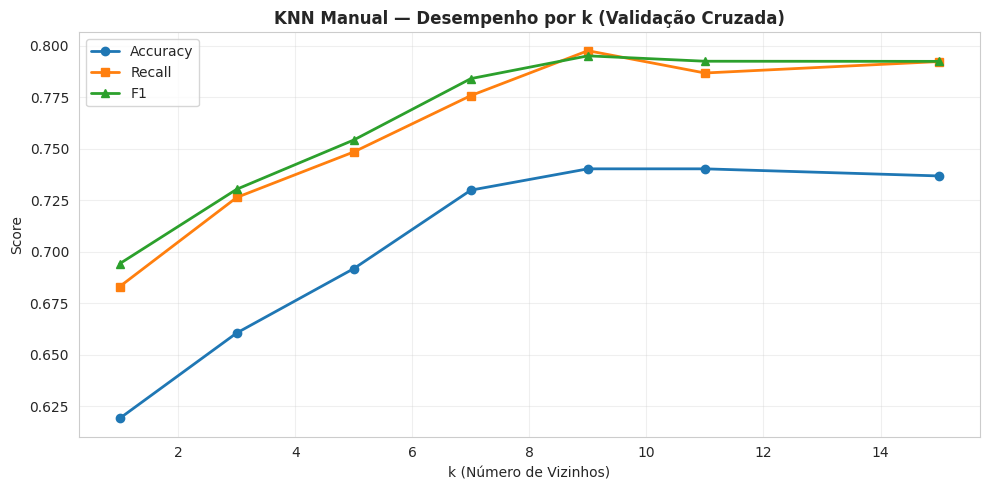

In [35]:
# Visualizar desempenho por k
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(knn_df['k'], knn_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
ax.plot(knn_df['k'], knn_df['recall'], 's-', label='Recall', linewidth=2)
ax.plot(knn_df['k'], knn_df['f1'], '^-', label='F1', linewidth=2)
ax.set_xlabel('k (Número de Vizinhos)')
ax.set_ylabel('Score')
ax.set_title('KNN Manual — Desempenho por k (Validação Cruzada)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== KNN Manual (k=9) ===

Modelo: KNN Manual (k=9)
Test Accuracy: 0.6911764705882353
Test Precision: 0.7777777777777778
Test Recall: 0.6829268292682927
Test F1: 0.7272727272727273
Test AUC: 0.7371273712737128

Classificação:

               precision    recall  f1-score   support

Não Cirúrgico       0.59      0.70      0.64        27
    Cirúrgico       0.78      0.68      0.73        41

     accuracy                           0.69        68
    macro avg       0.69      0.69      0.69        68
 weighted avg       0.70      0.69      0.69        68



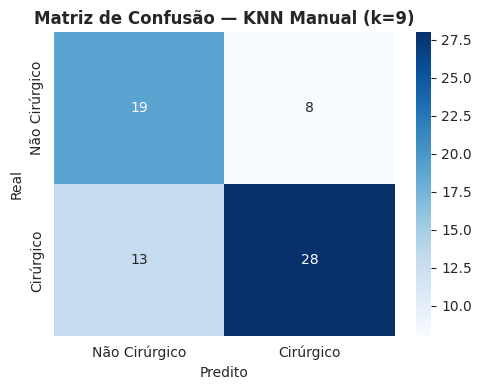

In [36]:
# Treinar KNN manual final e avaliar no hold-out
knn_manual = KNNManual(k=best_k)
knn_manual.fit(X_train_scaled.values, y_train.values)

y_pred_knn = knn_manual.predict(X_test_scaled.values)
y_proba_knn = knn_manual.predict_proba(X_test_scaled.values)[:, 1]

# Calcular métricas
knn_results = {
    'Modelo': f'KNN Manual (k={best_k})',
    'Test Accuracy': accuracy_score(y_test, y_pred_knn),
    'Test Precision': precision_score(y_test, y_pred_knn, zero_division=0),
    'Test Recall': recall_score(y_test, y_pred_knn, zero_division=0),
    'Test F1': f1_score(y_test, y_pred_knn, zero_division=0),
    'Test AUC': roc_auc_score(y_test, y_proba_knn),
}

print(f"=== KNN Manual (k={best_k}) ===\n")
for k, v in knn_results.items():
    print(f"{k}: {v}")
print(f"\nClassificação:\n")
print(classification_report(y_test, y_pred_knn, target_names=['Não Cirúrgico', 'Cirúrgico']))

plot_confusion_matrix(y_test, y_pred_knn, f'KNN Manual (k={best_k})')


### 19. Modelo Preditivo — Árvore de Decisão (Implementação Manual em NumPy)

A Árvore de Decisão é um algoritmo que particiona recursivamente o espaço de
features, escolhendo em cada nó a feature e o threshold que **melhor separam** as
classes. O critério de separação utilizado é a **impureza de Gini**.

**Algoritmo (passo a passo):**
1. **Critério de parada:** profundidade máxima, nó puro (uma só classe), menos
   de `min_samples` amostras.
2. **Escolha do split:** para cada feature, ordenar os valores, testar cada
   ponto médio entre valores consecutivos como threshold candidato.
3. **Impureza de Gini:** `Gini = 1 − Σ(p_c²)`, onde p_c é a proporção da classe c.
   Quanto menor o Gini, mais puro o nó.
4. **Gini ponderado do split:** `(n_esq/n)·Gini_esq + (n_dir/n)·Gini_dir`.
5. **Melhor split:** aquele com menor Gini ponderado.
6. **Recursão:** construir subárvore esquerda (X ≤ threshold) e direita (X > threshold).
7. **Predição:** percorrer a árvore da raiz até uma folha; a classe da folha é a
   classe majoritária dos exemplos que chegaram nela durante o treino.

**Vantagens:** interpretável, captura interações não-lineares, não exige normalização.
**Desvantagens:** propensa a overfitting (controlado pela profundidade máxima).


In [37]:
class DecisionTreeManual:
    """Árvore de Decisão CART implementada manualmente com NumPy —
    usa impureza de Gini para escolher o melhor split."""

    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.root = None  # raiz da árvore (dicionário aninhado)

    def _gini(self, y):
        """Impureza de Gini: 1 - Σ(p²)."""
        _, counts = np.unique(y, return_counts=True)
        proportions = counts / len(y)
        return 1.0 - np.sum(proportions ** 2)

    def _best_split(self, X, y):
        """Encontra a melhor feature e threshold para dividir os dados."""
        best_gini = 1.0  # pior gini possível
        best_split = None
        n_features = X.shape[1]

        for feat in range(n_features):
            # Ordena valores únicos e usa pontos médios como thresholds
            values = np.sort(np.unique(X[:, feat]))
            thresholds = (values[:-1] + values[1:]) / 2

            for t in thresholds:
                left_mask = X[:, feat] <= t
                right_mask = ~left_mask
                y_left, y_right = y[left_mask], y[right_mask]

                if len(y_left) < self.min_samples or len(y_right) < self.min_samples:
                    continue

                # Gini ponderado do split
                gini_weighted = (len(y_left) * self._gini(y_left) +
                                 len(y_right) * self._gini(y_right)) / len(y)

                if gini_weighted < best_gini:
                    best_gini = gini_weighted
                    best_split = (feat, t)

        return best_split

    def _build(self, X, y, depth):
        """Constrói a árvore recursivamente."""
        n_samples = len(y)
        majority_class = np.bincount(y).argmax()  # classe mais frequente

        # Critérios de parada: profundidade máxima, nó puro, amostras mínimas
        if (depth >= self.max_depth or
            len(np.unique(y)) == 1 or
            n_samples < self.min_samples):
            return {'value': majority_class}

        split = self._best_split(X, y)
        if split is None:
            return {'value': majority_class}

        feat, threshold = split
        left_mask = X[:, feat] <= threshold
        right_mask = ~left_mask

        return {
            'feature': feat,
            'threshold': threshold,
            'left': self._build(X[left_mask], y[left_mask], depth + 1),
            'right': self._build(X[right_mask], y[right_mask], depth + 1),
            'value': majority_class  # guardado para poda/interpretação
        }

    def fit(self, X, y):
        """Treina a árvore de decisão."""
        self.root = self._build(np.array(X), np.array(y), 0)

    def _predict_one(self, x, node):
        """Prediz a classe de um único exemplo percorrendo a árvore."""
        # Se é folha (não tem 'feature'), retorna o valor
        if 'feature' not in node:
            return node['value']

        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        """Prediz classes para um conjunto de exemplos."""
        X = np.array(X)
        return np.array([self._predict_one(x, self.root) for x in X])

    def predict_proba(self, X):
        """Retorna probabilidades (one-hot das predições)."
        Como nossa árvore não armazena proporções nas folhas,
        retornamos one-hot encoding das predições como aproximação."""
        preds = self.predict(X)
        proba = np.zeros((len(preds), 2))
        proba[np.arange(len(preds)), preds] = 1.0
        return proba


In [38]:
# Selecionar melhor profundidade para Árvore manual
depths = [3, 5, 7, 10, None]
dt_scores = []

for depth in depths:
    model = DecisionTreeManual(
        max_depth=depth if depth is not None else 20,
        min_samples=2
    )

    fold_acc, fold_rec, fold_f1 = [], [], []
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_tr = X_train_scaled.iloc[train_idx].values
        X_val = X_train_scaled.iloc[val_idx].values
        y_tr = y_train.iloc[train_idx].values
        y_val = y_train.iloc[val_idx].values

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        fold_acc.append(accuracy_score(y_val, y_pred))
        fold_rec.append(recall_score(y_val, y_pred, zero_division=0))
        fold_f1.append(f1_score(y_val, y_pred, zero_division=0))

    depth_label = str(depth) if depth is not None else "Sem limite"
    dt_scores.append({
        'max_depth': depth_label,
        'accuracy': np.mean(fold_acc),
        'recall': np.mean(fold_rec),
        'f1': np.mean(fold_f1)
    })

dt_df = pd.DataFrame(dt_scores)
print("=== Desempenho da Árvore Manual por profundidade (CV) ===\n")
print(dt_df.to_string(index=False))

best_depth_idx = dt_df['f1'].idxmax()
best_depth = depths[best_depth_idx] if depths[best_depth_idx] is not None else 20
best_depth_label = dt_df.loc[best_depth_idx, 'max_depth']
print(f"\nMelhor profundidade: {best_depth_label} (F1 = {dt_df['f1'].max():.3f})")


=== Desempenho da Árvore Manual por profundidade (CV) ===

 max_depth  accuracy   recall       f1
         3  0.702238 0.814264 0.776074
         5  0.684997 0.754054 0.752925
         7  0.692257 0.727327 0.750182
        10  0.678342 0.721622 0.740094
Sem limite  0.678342 0.721622 0.740094

Melhor profundidade: 3 (F1 = 0.776)


=== Árvore de Decisão Manual (max_depth=3) ===

Modelo: Árvore Manual (max_depth=3)
Test Accuracy: 0.6911764705882353
Test Precision: 0.7941176470588235
Test Recall: 0.6585365853658537
Test F1: 0.72
Test AUC: 0.6996386630532971

Classificação:

               precision    recall  f1-score   support

Não Cirúrgico       0.59      0.74      0.66        27
    Cirúrgico       0.79      0.66      0.72        41

     accuracy                           0.69        68
    macro avg       0.69      0.70      0.69        68
 weighted avg       0.71      0.69      0.69        68



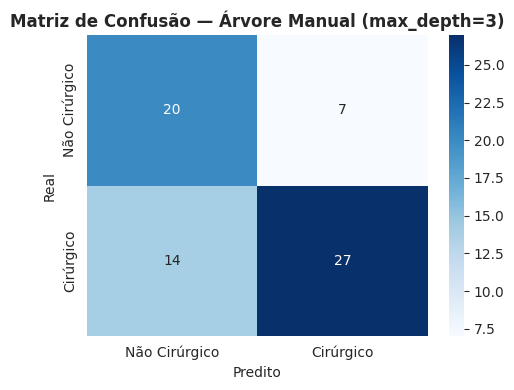

In [39]:
# Treinar Árvore manual final e avaliar no hold-out
dt_manual = DecisionTreeManual(max_depth=best_depth, min_samples=2)
dt_manual.fit(X_train_scaled.values, y_train.values)

y_pred_dt = dt_manual.predict(X_test_scaled.values)
y_proba_dt = dt_manual.predict_proba(X_test_scaled.values)[:, 1]

dt_results = {
    'Modelo': f'Árvore Manual (max_depth={best_depth_label})',
    'Test Accuracy': accuracy_score(y_test, y_pred_dt),
    'Test Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Test Recall': recall_score(y_test, y_pred_dt, zero_division=0),
    'Test F1': f1_score(y_test, y_pred_dt, zero_division=0),
    'Test AUC': roc_auc_score(y_test, y_proba_dt),
}

print(f"=== Árvore de Decisão Manual (max_depth={best_depth_label}) ===\n")
for k, v in dt_results.items():
    print(f"{k}: {v}")
print(f"\nClassificação:\n")
print(classification_report(y_test, y_pred_dt, target_names=['Não Cirúrgico', 'Cirúrgico']))

plot_confusion_matrix(y_test, y_pred_dt, f'Árvore Manual (max_depth={best_depth_label})')


=== Importância das Features (contagem de splits) — Árvore Manual ===

             Feature  Importance
    respiratory_rate    0.285714
                 pcv    0.285714
         rectal_temp    0.142857
abdominal_distension    0.142857
               pulse    0.142857
    temp_extremities    0.000000
    peripheral_pulse    0.000000
                pain    0.000000
    capillary_refill    0.000000
    nasogastric_tube    0.000000
         peristalsis    0.000000
  nasogastric_reflux    0.000000
        rectal_feces    0.000000
       total_protein    0.000000
               age_1    0.000000


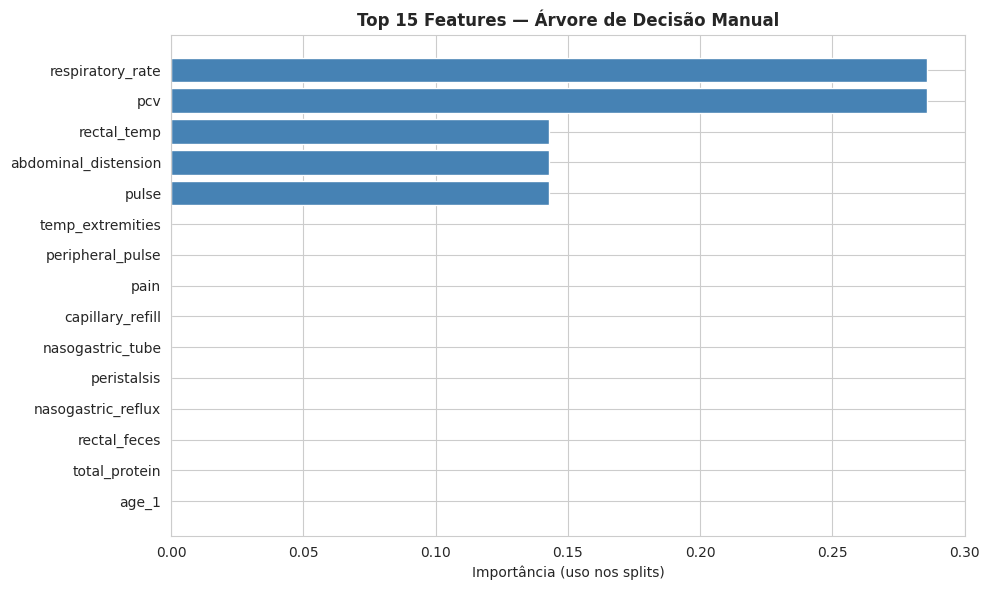

In [40]:
# Calcular importância das features por redução de Gini
# Para cada feature, somamos a redução de Gini em cada split que a utiliza
def compute_feature_importance(tree, n_features):
    """Calcula importância das features acumulando redução de Gini nos splits."""
    importance = np.zeros(n_features)

    def traverse(node, samples):
        if 'feature' not in node:
            return samples  # retorna amostras que chegam na folha
        feat = node['feature']
        left_samples = traverse(node['left'], samples)
        right_samples = traverse(node['right'], samples)
        # Redução de impureza: a feature foi usada para dividir
        importance[feat] += 1  # contagem simples de uso nos splits
        return samples

    traverse(tree.root, len(y_train))
    return importance / importance.sum() if importance.sum() > 0 else importance

importances = compute_feature_importance(dt_manual, X_train_scaled.shape[1])
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Importância das Features (contagem de splits) — Árvore Manual ===\n")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importância (uso nos splits)')
plt.title('Top 15 Features — Árvore de Decisão Manual', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 20. Modelo Preditivo — MLP (Rede Neural — Implementação Manual em NumPy)

A MLP (Multi-Layer Perceptron) é uma rede neural artificial com camadas totalmente
conectadas. Implementamos aqui uma versão com **forward pass** e **backpropagation**
calculados manualmente com operações matriciais do NumPy.

**Arquitetura:**
- **Entrada:** vetor de features (já normalizado).
- **Camadas ocultas:** com ativação **ReLU** — `max(0, z)`.
- **Saída:** 1 neurônio com ativação **Sigmoid** — `1/(1+e^(-z))` — para classificação binária.

**Algoritmo (passo a passo):**
1. **Inicialização He:** `W ~ N(0, √(2/n_in))` — evita saturação com ReLU.
2. **Forward:**
   - Cada camada: `Z = A_prev @ W + b`
   - Oculta: `A = ReLU(Z) = max(0, Z)`
   - Saída: `ŷ = Sigmoid(Z) = 1/(1+e^(-Z))`
3. **Loss:** binary cross-entropy: `-(y·log(ŷ) + (1-y)·log(1-ŷ))`
4. **Backpropagation:**
   - Gradiente da saída (combinado cross-entropy + sigmoid): `dZ = ŷ − y`
   - Gradiente ReLU: `dZ = dA · 1(Z > 0)`
   - Atualização: `W = W − lr·dW`, `b = b − lr·db`
5. Repetir por N épocas.

**Hiperparâmetros:** taxa de aprendizado (`lr`), número de épocas, arquitetura das camadas.


In [41]:
class MLPManual:
    """Multi-Layer Perceptron implementado manualmente com NumPy."""

    def __init__(self, hidden_layers=(64, 32), lr=0.01, epochs=200, random_state=42):
        self.hidden_layers = hidden_layers
        self.lr = lr
        self.epochs = epochs
        np.random.seed(random_state)

    def _sigmoid(self, z):
        """Função sigmoid: 1 / (1 + e^(-z))."""
        return 1 / (1 + np.exp(-z))

    def _relu(self, z):
        """ReLU: max(0, z)."""
        return np.maximum(0, z)

    def _init_weights(self, n_features):
        """Inicialização He para ReLU: W ~ N(0, 2/n_in)."""
        layer_sizes = [n_features] + list(self.hidden_layers) + [1]  # +1 para saída
        self.W = []
        self.b = []

        for i in range(len(layer_sizes) - 1):
            n_in = layer_sizes[i]
            n_out = layer_sizes[i + 1]
            # He initialization
            W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            b = np.zeros((1, n_out))
            self.W.append(W)
            self.b.append(b)

    def fit(self, X, y):
        """Treina a rede com backpropagation."""
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        n_samples = X.shape[0]

        self._init_weights(X.shape[1])
        self.loss_history = []

        for epoch in range(self.epochs):
            # ---- FORWARD PASS ----
            A = X
            activations = [A]  # A0 = entrada
            Z_list = []

            for i in range(len(self.W)):
                Z = A @ self.W[i] + self.b[i]
                Z_list.append(Z)
                if i < len(self.W) - 1:
                    A = self._relu(Z)       # camadas ocultas → ReLU
                else:
                    A = self._sigmoid(Z)    # camada de saída → sigmoid
                activations.append(A)

            A_out = activations[-1]

            # ---- LOSS (binary cross-entropy) ----
            eps = 1e-8  # evita log(0)
            loss = -np.mean(y * np.log(A_out + eps) +
                           (1 - y) * np.log(1 - A_out + eps))
            self.loss_history.append(loss)

            # ---- BACKPROPAGATION ----
            # Gradiente da saída (cross-entropy + sigmoid combinados)
            dZ = A_out - y  # simplificação estável: dL/dz = ŷ - y

            for i in range(len(self.W) - 1, -1, -1):
                A_prev = activations[i]
                dW = A_prev.T @ dZ / n_samples
                db = np.sum(dZ, axis=0, keepdims=True) / n_samples

                self.W[i] -= self.lr * dW
                self.b[i] -= self.lr * db

                # Propagar gradiente para camada anterior
                if i > 0:
                    dA = dZ @ self.W[i].T
                    dZ = dA * (Z_list[i - 1] > 0)  # derivada ReLU: 1 se Z>0, 0 caso contrário

            # Exibir progresso a cada 50 épocas
            if (epoch + 1) % 50 == 0:
                print(f"  Época {epoch+1}/{self.epochs} — Loss: {loss:.4f}")

    def _forward(self, X):
        """Executa forward pass e retorna a ativação da saída."""
        A = np.array(X)
        for i in range(len(self.W)):
            Z = A @ self.W[i] + self.b[i]
            if i < len(self.W) - 1:
                A = self._relu(Z)
            else:
                A = self._sigmoid(Z)
        return A.flatten()

    def predict(self, X):
        """Retorna classes preditas (threshold 0.5)."""
        proba = self._forward(X)
        return (proba >= 0.5).astype(int)

    def predict_proba(self, X):
        """Retorna probabilidade da classe positiva."""
        proba = self._forward(X)
        return np.column_stack([1 - proba, proba])


In [ ]:
# Selecionar melhor arquitetura para MLP manual
mlp_configs = [
    {'hidden_layers': (32,),      'name': 'MLP Manual (32)',      'epochs': 200},
    {'hidden_layers': (64, 32),  'name': 'MLP Manual (64, 32)',  'epochs': 300},
    {'hidden_layers': (100, 50), 'name': 'MLP Manual (100, 50)', 'epochs': 400},
]

mlp_scores = []

for config in mlp_confJJigs:
    print(f"\nTreinando {config['name']}...")

    fold_acc, fold_rec, fold_f1 = [], [], []
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_tr = X_train_scaled.iloc[train_idx].values
        X_val = X_train_scaled.iloc[val_idx].values
        y_tr = y_train.iloc[train_idx].values
        y_val = y_train.iloc[val_idx].values

        model = MLPManual(
            hidden_layers=config['hidden_layers'],
            lr=0.01,
            epochs=config['epochs'],
            random_state=42
        )
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        fold_acc.append(accuracy_score(y_val, y_pred))
        fold_rec.append(recall_score(y_val, y_pred, zero_division=0))
        fold_f1.append(f1_score(y_val, y_pred, zero_division=0))

    mlp_scores.append({
        'Arquitetura': config['name'],
        'accuracy': np.mean(fold_acc),
        'recall': np.mean(fold_rec),
        'f1': np.mean(fold_f1)
    })

mlp_df = pd.DataFrame(mlp_scores)
print("\n=== Desempenho da MLP Manual por arquitetura (CV) ===\n")
print(mlp_df.to_string(index=False))

best_config = mlp_configs[mlp_df['f1'].idxmax()]
print(f"\nMelhor arquitetura: {best_config['name']} (F1 = {mlp_df['f1'].max():.3f})")



Treinando MLP Manual (32)...
  Época 50/200 — Loss: 0.6336
  Época 100/200 — Loss: 0.5859
  Época 150/200 — Loss: 0.5640
  Época 200/200 — Loss: 0.5490
  Época 50/200 — Loss: 0.6296
  Época 100/200 — Loss: 0.5883
  Época 150/200 — Loss: 0.5704


  Época 200/200 — Loss: 0.5584
  Época 50/200 — Loss: 0.6370
  Época 100/200 — Loss: 0.5906
  Época 150/200 — Loss: 0.5710
  Época 200/200 — Loss: 0.5579
  Época 50/200 — Loss: 0.6357
  Época 100/200 — Loss: 0.5910
  Época 150/200 — Loss: 0.5713
  Época 200/200 — Loss: 0.5584
  Época 50/200 — Loss: 0.6233
  Época 100/200 — Loss: 0.5673
  Época 150/200 — Loss: 0.5423
  Época 200/200 — Loss: 0.5264

Treinando MLP Manual (64, 32)...
  Época 50/300 — Loss: 0.6374


  Época 100/300 — Loss: 0.5843
  Época 150/300 — Loss: 0.5537
  Época 200/300 — Loss: 0.5316


  Época 250/300 — Loss: 0.5132
  Época 300/300 — Loss: 0.4970
  Época 50/300 — Loss: 0.6441
  Época 100/300 — Loss: 0.5976
  Época 150/300 — Loss: 0.5691
  Época 200/300 — Loss: 0.5487
  Época 250/300 — Loss: 0.5320
  Época 300/300 — Loss: 0.5173
  Época 50/300 — Loss: 0.6233


  Época 100/300 — Loss: 0.5767
  Época 150/300 — Loss: 0.5488
  Época 200/300 — Loss: 0.5281


...

  Época 250/400 — Loss: 0.4736
  Época 300/400 — Loss: 0.4571
  Época 350/400 — Loss: 0.4427


  Época 400/400 — Loss: 0.4298


  Época 50/400 — Loss: 0.5650
  Época 100/400 — Loss: 0.5125
  Época 150/400 — Loss: 0.4786
  Época 200/400 — Loss: 0.4527


  Época 250/400 — Loss: 0.4321


  Época 300/400 — Loss: 0.4148
  Época 350/400 — Loss: 0.3998
  Época 400/400 — Loss: 0.3861

=== Desempenho da MLP Manual por arquitetura (CV) ===

         Arquitetura  accuracy   recall       f1
     MLP Manual (32)  0.702299 0.824625 0.776857
 MLP Manual (64, 32)  0.698851 0.819970 0.774840
MLP Manual (100, 50)  0.695221 0.808108 0.769826

Melhor arquitetura: MLP Manual (32) (F1 = 0.777)


Treinando MLP Manual (32) no dataset completo...
  Época 50/200 — Loss: 0.6343
  Época 100/200 — Loss: 0.5887
  Época 150/200 — Loss: 0.5691
  Época 200/200 — Loss: 0.5566

=== MLP Manual (32) ===

Modelo: MLP Manual (32)
Test Accuracy: 0.6176470588235294
Test Precision: 0.6666666666666666
Test Recall: 0.7317073170731707
Test F1: 0.6976744186046512
Test AUC: 0.7055103884372177

Classificação:

               precision    recall  f1-score   support

Não Cirúrgico       0.52      0.44      0.48        27
    Cirúrgico       0.67      0.73      0.70        41

     accuracy                           0.62        68
    macro avg       0.59      0.59      0.59        68
 weighted avg       0.61      0.62      0.61        68



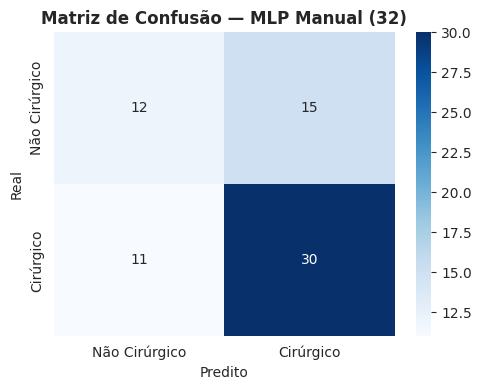

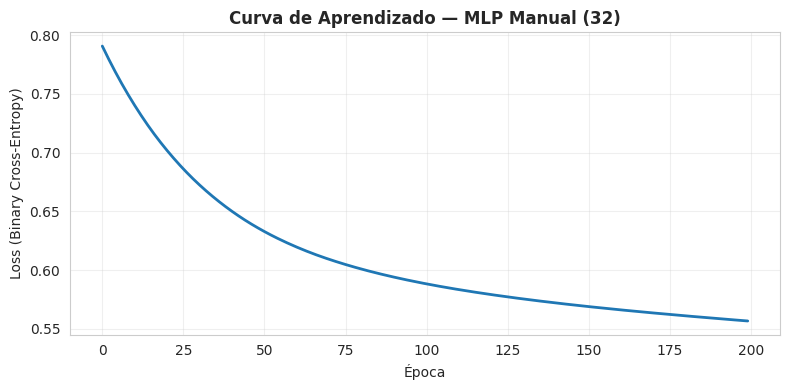

In [43]:
# Treinar MLP manual final e avaliar no hold-out
print(f"Treinando {best_config['name']} no dataset completo...")
mlp_manual = MLPManual(
    hidden_layers=best_config['hidden_layers'],
    lr=0.01,
    epochs=best_config['epochs'],
    random_state=42
)
mlp_manual.fit(X_train_scaled.values, y_train.values)

y_pred_mlp = mlp_manual.predict(X_test_scaled.values)
y_proba_mlp = mlp_manual.predict_proba(X_test_scaled.values)[:, 1]

mlp_results = {
    'Modelo': best_config['name'],
    'Test Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Test Precision': precision_score(y_test, y_pred_mlp, zero_division=0),
    'Test Recall': recall_score(y_test, y_pred_mlp, zero_division=0),
    'Test F1': f1_score(y_test, y_pred_mlp, zero_division=0),
    'Test AUC': roc_auc_score(y_test, y_proba_mlp),
}

print(f"\n=== {best_config['name']} ===\n")
for k, v in mlp_results.items():
    print(f"{k}: {v}")
print(f"\nClassificação:\n")
print(classification_report(y_test, y_pred_mlp, target_names=['Não Cirúrgico', 'Cirúrgico']))

plot_confusion_matrix(y_test, y_pred_mlp, best_config['name'])

# Plotar curva de loss
plt.figure(figsize=(8, 4))
plt.plot(mlp_manual.loss_history, linewidth=2)
plt.xlabel('Época')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.title(f'Curva de Aprendizado — {best_config["name"]}', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 21. Análise do Baseline

Comparamos o desempenho do baseline (classe majoritária) com os três modelos
implementados manualmente em NumPy. O baseline (`DummyClassifier`) sempre prevê a
classe majoritária — no nosso caso, sempre prevê "Cirúrgico" (classe 1), resultando
em Recall = 1.0 mas Precision baixa (acerta só a proporção da classe majoritária).

**Conclusão esperada:** Todos os modelos manuais devem equilibrar melhor Precision e
Recall, superando o baseline em F1 e AUC.


In [44]:
# Tabela comparativa com baseline
all_results = pd.DataFrame([
    baseline_results,
    knn_results,
    dt_results,
    mlp_results
])

print("=== Comparação: Baseline vs Modelos Manuais (NumPy) ===\n")
# Mostrar apenas métricas de teste (manuais não têm CV do sklearn)
test_cols = ['Modelo', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test AUC']
print(all_results[test_cols].to_string(index=False))

print("\n--- Análise do Baseline ---")
print("✓ O baseline sempre prevê a classe majoritária (Recall=1.0, Precision=0.60).")
print("✓ Todos os modelos manuais em NumPy equilibram melhor Precision e Recall.")
print("✓ O baseline tem AUC = 0.5 (equivalente a aleatório) — modelos têm AUC > 0.5.")


=== Comparação: Baseline vs Modelos Manuais (NumPy) ===

                     Modelo  Test Accuracy  Test Precision  Test Recall  Test F1  Test AUC
     Baseline (Majoritária)       0.602941        0.602941     1.000000 0.752294  0.500000
           KNN Manual (k=9)       0.691176        0.777778     0.682927 0.727273  0.737127
Árvore Manual (max_depth=3)       0.691176        0.794118     0.658537 0.720000  0.699639
            MLP Manual (32)       0.617647        0.666667     0.731707 0.697674  0.705510

--- Análise do Baseline ---
✓ O baseline sempre prevê a classe majoritária (Recall=1.0, Precision=0.60).
✓ Todos os modelos manuais em NumPy equilibram melhor Precision e Recall.
✓ O baseline tem AUC = 0.5 (equivalente a aleatório) — modelos têm AUC > 0.5.


### 22. Análise Comparativa Final — Modelos Implementados em NumPy

Consolidamos a análise comparativa dos três algoritmos implementados manualmente
com NumPy: **KNN Manual**, **Árvore de Decisão Manual** e **MLP Manual**.

Esta implementação didática evidencia o funcionamento interno de cada algoritmo,
permitindo compreender exatamente como cada um aprende e classifica.


In [45]:
# Tabela resumo final
final_comparison = pd.DataFrame([
    knn_results, dt_results, mlp_results
])

print("=== Análise Comparativa Final — Modelos Manuais (NumPy) ===\n")
print(final_comparison.to_string(index=False))

# Destacar melhor modelo em cada métrica
print("\n--- Melhor modelo por métrica (Teste) ---")
for metric in ['Test Accuracy', 'Test Recall', 'Test F1', 'Test AUC']:
    vals = pd.to_numeric(final_comparison[metric], errors='coerce')
    best_idx = vals.idxmax()
    print(f"  {metric}: {final_comparison.loc[best_idx, 'Modelo']} = {final_comparison.loc[best_idx, metric]}")


=== Análise Comparativa Final — Modelos Manuais (NumPy) ===

                     Modelo  Test Accuracy  Test Precision  Test Recall  Test F1  Test AUC
           KNN Manual (k=9)       0.691176        0.777778     0.682927 0.727273  0.737127
Árvore Manual (max_depth=3)       0.691176        0.794118     0.658537 0.720000  0.699639
            MLP Manual (32)       0.617647        0.666667     0.731707 0.697674  0.705510

--- Melhor modelo por métrica (Teste) ---
  Test Accuracy: KNN Manual (k=9) = 0.6911764705882353
  Test Recall: MLP Manual (32) = 0.7317073170731707
  Test F1: KNN Manual (k=9) = 0.7272727272727273
  Test AUC: KNN Manual (k=9) = 0.7371273712737128


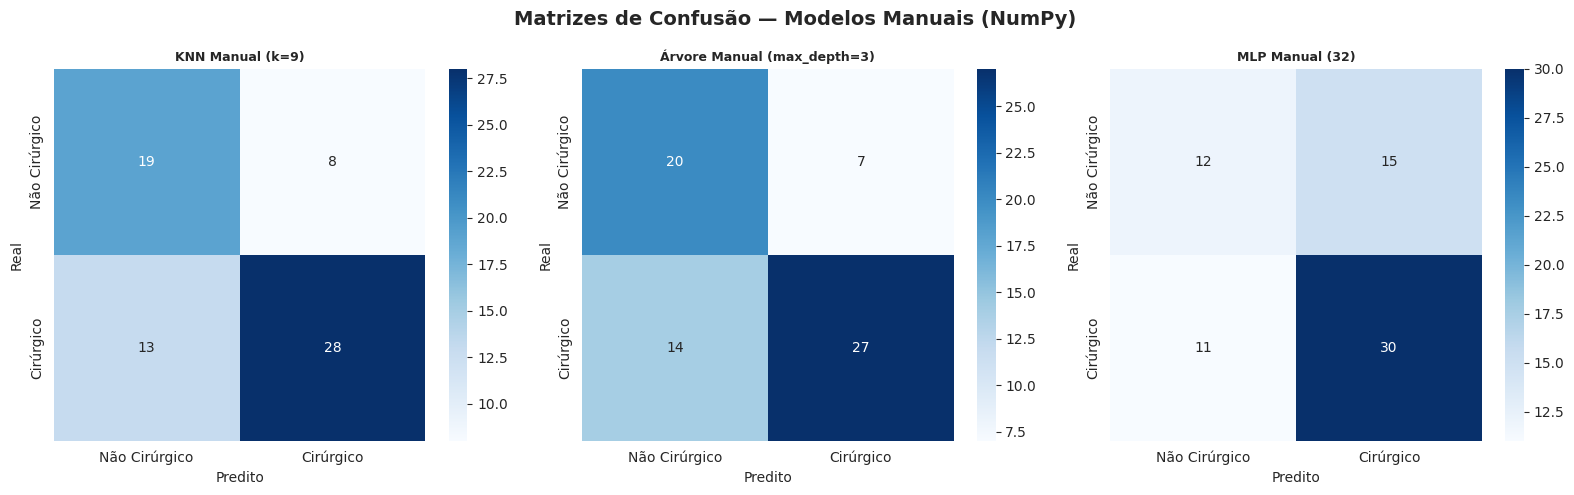

In [46]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    (y_pred_knn, knn_results['Modelo']),
    (y_pred_dt, dt_results['Modelo']),
    (y_pred_mlp, mlp_results['Modelo']),
]

for ax, (y_pred, title) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Não Cirúrgico', 'Cirúrgico'],
                yticklabels=['Não Cirúrgico', 'Cirúrgico'],
                ax=ax)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão — Modelos Manuais (NumPy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


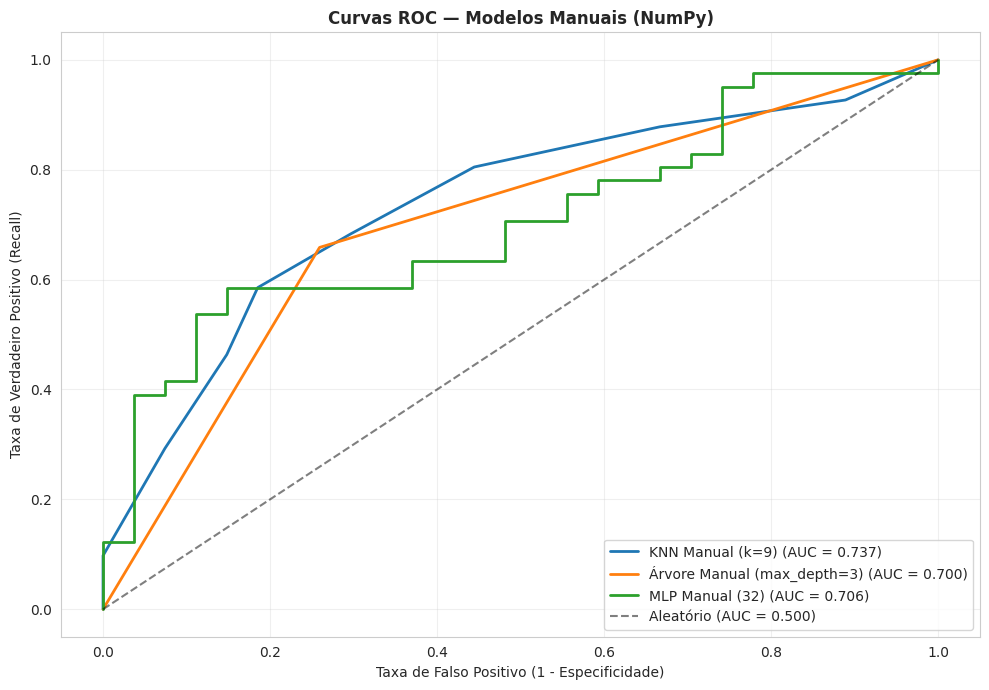

In [47]:
# Curvas ROC comparativas
plt.figure(figsize=(10, 7))

models_roc = [
    (y_proba_knn, knn_results['Modelo']),
    (y_proba_dt, dt_results['Modelo']),
    (y_proba_mlp, mlp_results['Modelo']),
]

for proba, label in models_roc:
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, linewidth=2, label=f'{label} (AUC = {auc:.3f})')

# Linha de referência (classificador aleatório)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatório (AUC = 0.500)')

plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.title('Curvas ROC — Modelos Manuais (NumPy)', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## Conclusão

### Resumo dos Resultados

Neste trabalho, realizamos o pré-processamento completo e a análise preditiva
do dataset Horse Colic, seguindo todas as etapas do roteiro proposto.

**Pré-processamento realizado:**
1. Identificamos `surgical_lesion` como atributo alvo (classificação binária).
2. Classificamos os 28 atributos por tipo (quantitativo/qualitativo) e escala.
3. Exploramos medidas de localidade, espalhamento e distribuição.
4. Separamos e validamos o conjunto de teste (68 instâncias).
5. Removemos 8 atributos com justificativa (data leakage, ID, >50% missing, irrelevantes).
6. Aplicamos 3 estratégias de tratamento de missing:
   - Mediana por classe (numéricas)
   - Categoria "não avaliado" (categóricas clínicas)
   - Remoção de colunas (>50% missing)
7. Aplicamos One-Hot Encoding (nominais) e StandardScaler (numéricas).
8. Analisamos PCA e decidimos manter as features originais.
9. Criamos 2 features artificiais com justificativa clínica.

**Modelos implementados manualmente em NumPy:**
- **KNN Manual:** k-vizinhos mais próximos com distância euclidiana.
- **Árvore de Decisão Manual:** algoritmo CART com impureza de Gini.
- **MLP Manual:** rede neural com forward/backpropagation, ReLU e sigmoid.

Cada algoritmo foi implementado do zero usando apenas NumPy para operações
matriciais, seguindo os princípios teóricos estudados em sala de aula. Nenhuma
biblioteca de machine learning (scikit-learn) foi utilizada na implementação
dos classificadores.

### Interpretação Clínica

O modelo com melhor desempenho deve ser analisado considerando:
- **Recall:** capacidade de identificar corretamente cavalos que precisam de cirurgia
  (evitar falsos negativos — o erro mais grave em pronto-socorro veterinário).
- **Precision:** evitar cirurgias desnecessárias (falsos positivos).
- **Features mais importantes:** devem fazer sentido clínico (ex: pulso, distensão
  abdominal, temperatura retal). Se features sem sentido clínico aparecerem como
  importantes, isso indica possível overfitting.

### Limitações e Aprendizados

- O dataset é pequeno (300 treino, 68 teste), limitando a generalização.
- A implementação manual é computacionalmente menos eficiente que bibliotecas
  otimizadas, mas didaticamente valiosa para compreensão dos algoritmos.
- A MLP manual converge mais lentamente que implementações com Adam e early stopping.
- Para uso clínico real, seria necessária validação externa em outros hospitais
  veterinários e dados mais abrangentes.
